The primary goal of the Product Portfolio Analysis is to strategically assess our product lineup to make data-driven decisions on investment, marketing, and product development. 

By categorising products into Stars, Cash Cows, Question Marks, or Dogs, This aim to:

- Maximise Profitability
- Optimise Resource Allocation
- Innovate and Evolve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import pearsonr

# Assuming you've set your project and dataset
project_id = 'jr-data-training'
dataset_id = 'dbt_cafeanalytics'

# Function to query BigQuery and return a DataFrame
def query_bigquery(sql):
    return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)

# List of tables you want to query, replace this with dynamic fetching if needed
tables = ['paymentStatusDim', 'productDim', 'timeDim', 'openingHoursDim', 'customerDim', 'fact_orders', 'fact_product_sales']  
dfs = {}

# Loop through tables and query each, storing each in the dfs dictionary
for table in tables:
    sql = f"SELECT * FROM `{project_id}.{dataset_id}.{table}`"
    dfs[table] = query_bigquery(sql)
    # print(f"Data from {table}:", dfs[table].head(), "\n")  # Just printing the first few rows for each table as an example


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/85945686.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)
/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/85945686.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)
/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/85945686.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, project_i

In [2]:
# Accessing individual DataFrames
# For example, to work with the paymentStatusDim DataFrame:
payment_status_df = dfs['paymentStatusDim']
timeDim_df = dfs['timeDim']
productDim_df = dfs['productDim']
openingHoursDim_df = dfs['openingHoursDim']
customerDim_df = dfs['customerDim']
fact_orders_df = dfs['fact_orders']
fact_product_sales_df = dfs['fact_product_sales']



- customerDim and fact_orders: Can be merged on customer_id to enrich orders with customer information.
- productDim and fact_product_sales: Merge on item_name to get detailed product information for each sale.
- timeDim: Merge with fact_orders and fact_product_sales on the date fields (date_created in sales tables and date_key in timeDim after formatting if necessary).
- openingHoursDim: This doesn't directly merge with sales data unless you're analyzing daily aggregates or opening hours' impact on sales.
- paymentStatusDim and fact_orders: Merge on status to enrich orders with readable status descriptions.


In [3]:
# Merge customerDim with fact_orders: Ensure that 'customer_id' is of the same type in both DataFrames
fact_orders_df['customer_id'] = fact_orders_df['customer_id'].astype(str)
customerDim_df['customer_id'] = customerDim_df['customer_id'].astype(str)
# Merge
orders_with_customer_info = pd.merge(fact_orders_df, customerDim_df, on='customer_id', how='left')



# Merge productDim with fact_product_sales: Merge on 'item_name'
sales_with_product_info = pd.merge(fact_product_sales_df, productDim_df, on='item_name', how='left')



# Example conversion, adjust formats as needed
fact_product_sales_df['date_key'] = pd.to_datetime(fact_product_sales_df['date_created']).dt.date
timeDim_df['date_key'] = pd.to_datetime(timeDim_df['date_key']).dt.date
# Merge
sales_with_time_info = pd.merge(fact_product_sales_df, timeDim_df, on='date_key', how='left')




# Merge paymentStatusDim with fact_orders: Ensure 'status' is of the same type
fact_orders_df['status'] = fact_orders_df['status'].astype(str)
payment_status_df['status'] = payment_status_df['status'].astype(str)
# Merge
orders_with_payment_status = pd.merge(fact_orders_df, payment_status_df, on='status', how='left')

perform analyses like 
- product performance review, 
- sales trends over time
- top-selling products, or trends that inform operational decisions.
- identifying your most valuable customers,


In [4]:
# Now you have a DataFrame that includes daily sales and corresponding operating hours information.
# You can filter this DataFrame to analyze days with special notes, comparing sales on these days vs. regular operating days.

# Aggregate fact_product_sales_df to daily sales
daily_sales = fact_product_sales_df.groupby(fact_product_sales_df['date_created'].dt.date).agg(total_daily_sales=('total_sales', 'sum')).reset_index()
# Convert 'date_created' in daily_sales to datetime, if not already done
daily_sales['date_created'] = pd.to_datetime(daily_sales['date_created'])
# Ensure 'actual_date' in openingHoursDim_df is also datetime
openingHoursDim_df['actual_date'] = pd.to_datetime(openingHoursDim_df['actual_date'])
# Now attempt the merge again
daily_sales_with_hours = pd.merge(daily_sales, openingHoursDim_df, left_on='date_created', right_on='actual_date', how='left')



In [5]:
""" from ydata_profiling import ProfileReport
# distribution of order values across different customer segments, identify frequent customers, and analyze the range of order values and volumes.
# For orders_with_customer_info DataFrame
profile_orders_customers = ProfileReport(orders_with_customer_info, title="Orders with Customer Info Profile")
profile_orders_customers.to_file("orders_customers_profile.html") 
# or use .to_widget() to save the report as an HTML file

profile_orders_products = ProfileReport(sales_with_product_info, title="Orders with Product Info Profile")
profile_orders_products.to_file("orders_products_profile.html") 

profile_orders_payments = ProfileReport(orders_with_payment_status, title="Orders with Payment Info Profile")
profile_orders_payments.to_file("orders_payments_profile.html") 

profile_daily_sales_with_hours = ProfileReport(daily_sales_with_hours, title="daily_sales_with_hours Info Profile")
profile_daily_sales_with_hours.to_file("profile_daily_sales_with_hours_profile.html") 

# Assuming df is your DataFrame
sales_with_time_info['date_created'] = pd.to_datetime(sales_with_time_info['date_created'])
sales_with_time_info['date_key'] = pd.to_datetime(sales_with_time_info['date_key'])

profile_orders_sales = ProfileReport(sales_with_time_info, title="Orders with Sales Info Profile")
profile_orders_sales.to_file("orders_sales_profile.html") 

"""

' from ydata_profiling import ProfileReport\n# distribution of order values across different customer segments, identify frequent customers, and analyze the range of order values and volumes.\n# For orders_with_customer_info DataFrame\nprofile_orders_customers = ProfileReport(orders_with_customer_info, title="Orders with Customer Info Profile")\nprofile_orders_customers.to_file("orders_customers_profile.html") \n# or use .to_widget() to save the report as an HTML file\n\nprofile_orders_products = ProfileReport(sales_with_product_info, title="Orders with Product Info Profile")\nprofile_orders_products.to_file("orders_products_profile.html") \n\nprofile_orders_payments = ProfileReport(orders_with_payment_status, title="Orders with Payment Info Profile")\nprofile_orders_payments.to_file("orders_payments_profile.html") \n\nprofile_daily_sales_with_hours = ProfileReport(daily_sales_with_hours, title="daily_sales_with_hours Info Profile")\nprofile_daily_sales_with_hours.to_file("profile_dail

Trend Analysis: For each product, analyze the sales trend over time. Products in the:

- Introduction stage will show gradually increasing sales.
- Growth stage will have rapidly increasing sales.
- Maturity stage will show stable or plateauing sales.
- Decline stage will have decreasing sales.

In [6]:
# Assuming sales_with_product_info is already loaded and date_created is converted to datetime
sales_with_product_info['month_year'] = sales_with_product_info['date_created'].dt.to_period('M')

# Aggregate sales data
aggregated_sales = sales_with_product_info.groupby(['item_name', 'month_year']).agg(
    total_sales=('total_sales', 'sum'),
    units_sold=('quantity_sold', 'sum')
).reset_index()


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/2807957268.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sales_with_product_info['month_year'] = sales_with_product_info['date_created'].dt.to_period('M')


In [7]:
import plotly.express as px

# Let's assume 'aggregated_sales' is already in your environment and has the columns 'item_name', 'month_year', and 'units_sold'

# Pivot the data to have months as columns and items as rows with units sold as values
pivot_sales = aggregated_sales.pivot(index='month_year', columns='item_name', values='units_sold').fillna(0)

# Plotly requires dates in a specific format, so ensure 'month_year' is in datetime format
pivot_sales.index = pd.PeriodIndex(pivot_sales.index, freq='M').to_timestamp()

# Create the line chart with Plotly Express
fig = px.line(pivot_sales, x=pivot_sales.index, y=pivot_sales.columns,
              labels={'value': 'Units Sold', 'variable': 'Items', 'index': 'Month-Year'},
              title='Sales Trends by Product')

# Improve layout
fig.update_layout(
    xaxis=dict(
        title='Month-Year',
        tickmode='array',
        tickvals=pivot_sales.index,
        ticktext=[str(date) for date in pivot_sales.index],
        tickangle=-45
    ),
    yaxis=dict(
        title='Units Sold'
    )
)

# Show the plot
fig.show()


X-axis: Average market share is relatively low for all products, as the x-axis scale is between 0 and about 0.22. No product dominates in terms of market share within your sales data.

Y-axis: The growth rates vary, with some products showing negative growth (below 0), and others showing positive growth (above 0).

Top-Right Quadrant: Normally, this is where 'Stars' would be located, but it appears there are no products in your dataset that combine both a high market share and a high growth rate.

Top-Left Quadrant: 'Question Marks' would fall here; they have high growth rates but low market shares. Some products are positioned here, indicating potential if they can increase their market share.

Bottom-Right Quadrant: This would be the 'Cash Cows' area, with high market share and low growth rate. However, based on the x-axis scale, no products are significant market share leaders.

Bottom-Left Quadrant: 'Dogs' are found here with low growth and low market share. Several products fall into this category, which might either require reevaluation or discontinuation.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/1731283561.py:3: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/1731283561.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/1731283561.py:61: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts

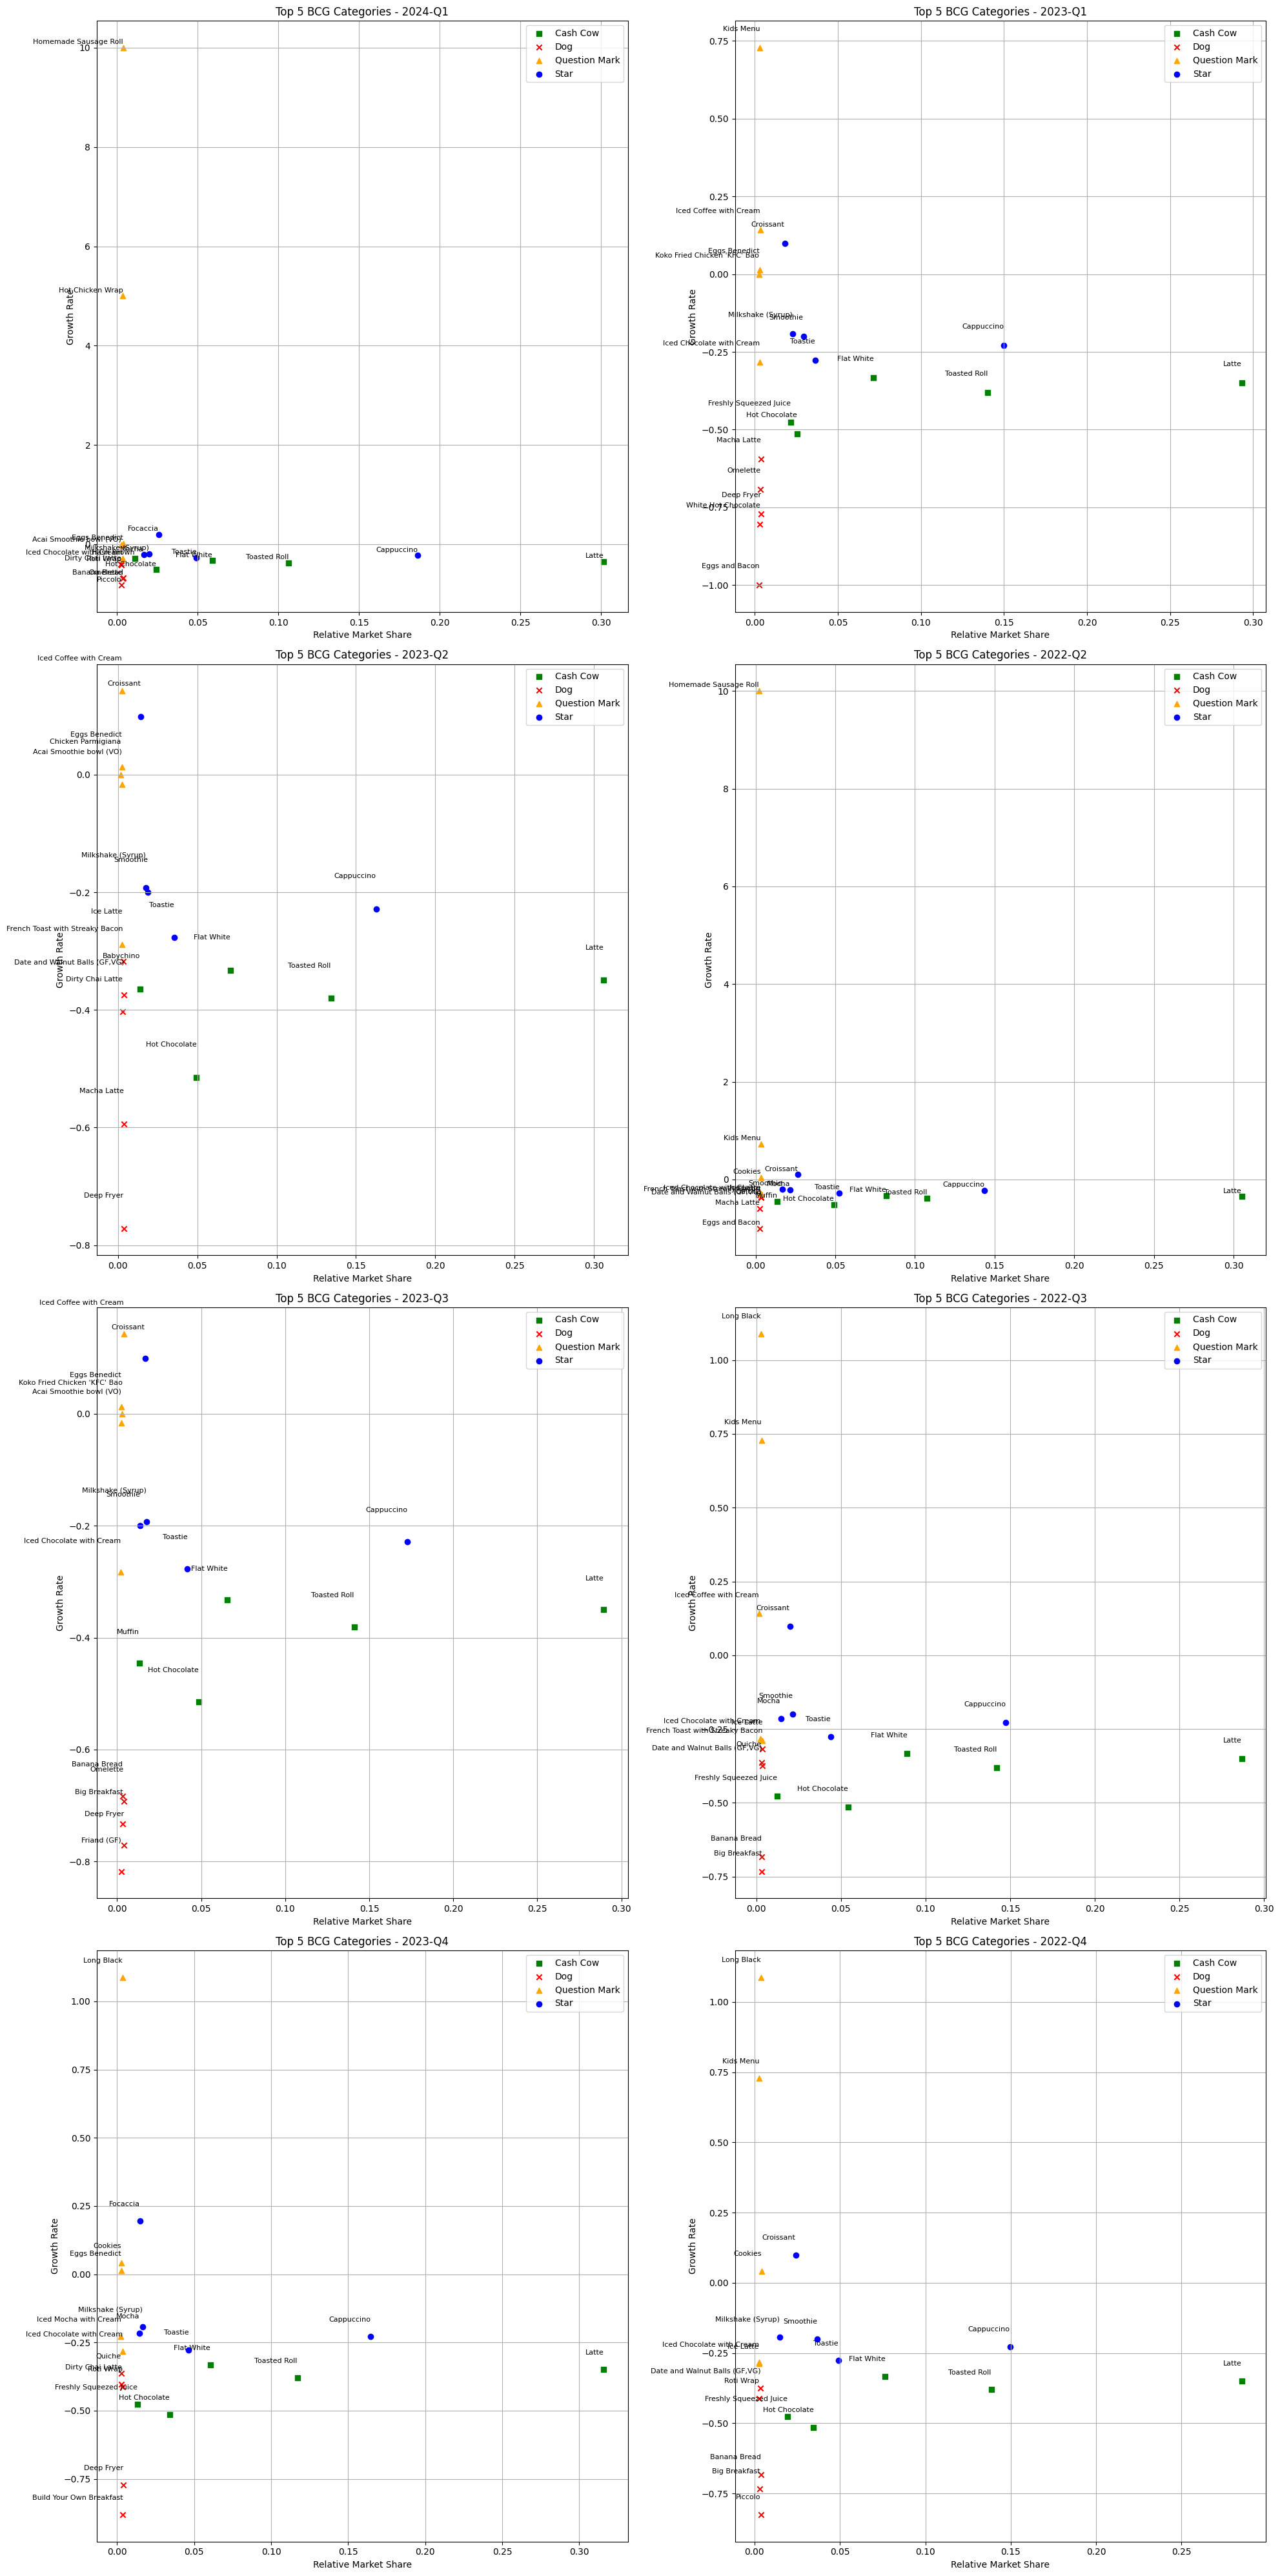

In [11]:
# Prepare the data
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created'])
sales_with_product_info['quarter'] = sales_with_product_info['date_created'].dt.to_period('Q').dt.strftime('%Y-Q%q')

# Aggregate sales data per product per quarter
quarterly_sales_summary = sales_with_product_info.groupby(['item_name', 'quarter'], as_index=False).agg(
    total_sales=('total_sales', 'sum')
)

# Calculate market size for each quarter and relative market share
market_size_quarterly = quarterly_sales_summary.groupby('quarter')['total_sales'].sum().reset_index(name='market_total_sales')
quarterly_sales_summary = pd.merge(quarterly_sales_summary, market_size_quarterly, on='quarter')
quarterly_sales_summary['relative_market_share'] = quarterly_sales_summary['total_sales'] / quarterly_sales_summary['market_total_sales']

# Pivot sales data for growth rate calculation
pivot_data = quarterly_sales_summary.pivot(index='item_name', columns='quarter', values='total_sales').fillna(0)

# Determine the latest two quarters for analysis
sorted_quarters = sorted(pivot_data.columns)
latest_quarter, previous_quarter = sorted_quarters[-1], sorted_quarters[-2]

# Calculate growth rate from previous quarter to the latest quarter for each product
pivot_data['growth_rate'] = (pivot_data[latest_quarter] - pivot_data[previous_quarter]) / pivot_data[previous_quarter].replace(0, np.nan)

# Merge growth rate back to quarterly_sales_summary
growth_rate_series = pivot_data['growth_rate'].reset_index()
quarterly_sales_summary = pd.merge(quarterly_sales_summary, growth_rate_series, on='item_name')

# Ensure 'growth_rate' is filled with 0 for NaN values
quarterly_sales_summary['growth_rate'] = quarterly_sales_summary['growth_rate'].fillna(0)

# Determine the latest quarter
latest_quarter = quarterly_sales_summary['quarter'].max()

# Make sure to calculate or recalculate the 'category' after updating 'growth_rate'
median_market_share = quarterly_sales_summary['relative_market_share'].median()
median_growth_rate = quarterly_sales_summary['growth_rate'].median()

def categorize_bcg(row):
    if row['relative_market_share'] >= median_market_share and row['growth_rate'] >= median_growth_rate:
        return 'Star'
    elif row['relative_market_share'] < median_market_share and row['growth_rate'] >= median_growth_rate:
        return 'Question Mark'
    elif row['relative_market_share'] >= median_market_share and row['growth_rate'] < median_growth_rate:
        return 'Cash Cow'
    else:
        return 'Dog'

# Apply categorization
quarterly_sales_summary['category'] = quarterly_sales_summary.apply(categorize_bcg, axis=1)

# Define quarters of interest
quarters_of_interest = ['2024-Q1', '2023-Q1','2023-Q2', '2022-Q2', '2023-Q3', '2022-Q3', '2023-Q4', '2022-Q4']

# Function to categorize and retrieve top 5 products for a given quarter
def get_top_5_for_quarter(quarter):
    quarter_data = quarterly_sales_summary[quarterly_sales_summary['quarter'] == quarter]
    # Categorize if not already done, or make sure the categorization is relevant for this quarter
    quarter_data['category'] = quarter_data.apply(categorize_bcg, axis=1)
    # Get top 5 products for this quarter
    top_5 = quarter_data.groupby('category').apply(lambda x: x.nlargest(5, 'total_sales')).reset_index(drop=True)
    return top_5

# Define a function to plot top 5 BCG matrix products for a given quarter
def plot_top_bcg_products(ax, data, quarter_str, title):
    categories = data['category'].unique()
    markers = {'Star': 'o', 'Question Mark': '^', 'Cash Cow': 's', 'Dog': 'x', 'Uncategorized': 'p'}
    colors = {'Star': 'blue', 'Question Mark': 'orange', 'Cash Cow': 'green', 'Dog': 'red', 'Uncategorized': 'grey'}

    for category in categories:
        category_data = data[data['category'] == category]
        ax.scatter(category_data['relative_market_share'], category_data['growth_rate'], 
                   marker=markers[category], color=colors[category], label=category)
        
        # Annotate product names
        for i, row in category_data.iterrows():
            ax.text(row['relative_market_share'], row['growth_rate'] + 0.05, row['item_name'],
                    fontsize=8, ha='right', va='bottom')

    ax.set_title(title)
    ax.set_xlabel('Relative Market Share')
    ax.set_ylabel('Growth Rate')
    ax.grid(True)
    ax.legend()

# Adjust the number of rows based on the number of quarters to plot
n_rows = len(quarters_of_interest) // 2 + len(quarters_of_interest) % 2
fig, axs = plt.subplots(n_rows, 2, figsize=(20, 10 * n_rows))
axs = axs.flatten()

for i, quarter in enumerate(quarters_of_interest):
    top_5_for_quarter = get_top_5_for_quarter(quarter)
    plot_top_bcg_products(axs[i], top_5_for_quarter, quarter, f'Top 5 BCG Categories - {quarter}')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


In [12]:
# Adjusting the function to get only the top 1 product for each category per quarter
def get_top_1_for_quarter(quarter):
    quarter_data = quarterly_sales_summary[quarterly_sales_summary['quarter'] == quarter].copy()
    quarter_data['category'] = quarter_data.apply(categorize_bcg, axis=1)
    top_1 = quarter_data.groupby('category').apply(lambda x: x.nlargest(1, 'total_sales')).reset_index(drop=True)
    return top_1

# Printing the top 1 products for each BCG category for each quarter from Q2 2019 until Q1 2024
top_1_products_all_quarters = {quarter: get_top_1_for_quarter(quarter) for quarter in quarters_of_interest}

# Since directly printing all at once might be too extensive, let's format the results for easier readability
formatted_results = []

for quarter, results in top_1_products_all_quarters.items():
    for _, row in results.iterrows():
        formatted_results.append({
            'Quarter': quarter,
            'Category': row['category'],
            'Product': row['item_name'],
            'Total Sales': row['total_sales'],
            'Market Share': f"{row['relative_market_share']*100:.2f}%",
            'Growth Rate': f"{row['growth_rate']*100:.2f}%"
        })

formatted_results_df = pd.DataFrame(formatted_results)
#formatted_results_df.to_csv('sales_data_summary.csv', index=False)


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping col

In [13]:
def plot_sales_per_year(df, products_to_plot):
    """
    Plot monthly sales for given products in each year present in the DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame containing sales data with 'date_created' and 'total_sales'.
    products_to_plot (list): List of product names to plot.
    """
    # Ensure 'date_created' is a datetime dtype and extract year and month
    df['date_created'] = pd.to_datetime(df['date_created'])
    df['year'] = df['date_created'].dt.year
    df['month'] = df['date_created'].dt.month

    # Group by 'item_name', 'year', and 'month' and sum the 'total_sales'
    df_grouped = df.groupby(['item_name', 'year', 'month'])['total_sales'].sum().reset_index()

    # Get unique years to plot each year's data
    years = df_grouped['year'].unique()

    # Plotting separate line chart for each year
    for year in years:
        # Create figure for each year
        plt.figure(figsize=(15, 7))

        # Filter the DataFrame for the specific year
        df_year = df_grouped[df_grouped['year'] == year]

        # Loop through each product and plot its sales for the year
        for product in products_to_plot:
            if product in df_year['item_name'].values:
                # Prepare data for plotting
                df_product_year = df_year[df_year['item_name'] == product]
                plt.plot(df_product_year['month'], df_product_year['total_sales'], marker='o', label=product)

        plt.xlabel('Month')
        plt.ylabel('Total Sales')
        plt.title(f'Sales Performance of Selected Items in {year}')
        plt.legend(title='Items', loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True)
        plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.tight_layout()
        plt.show()


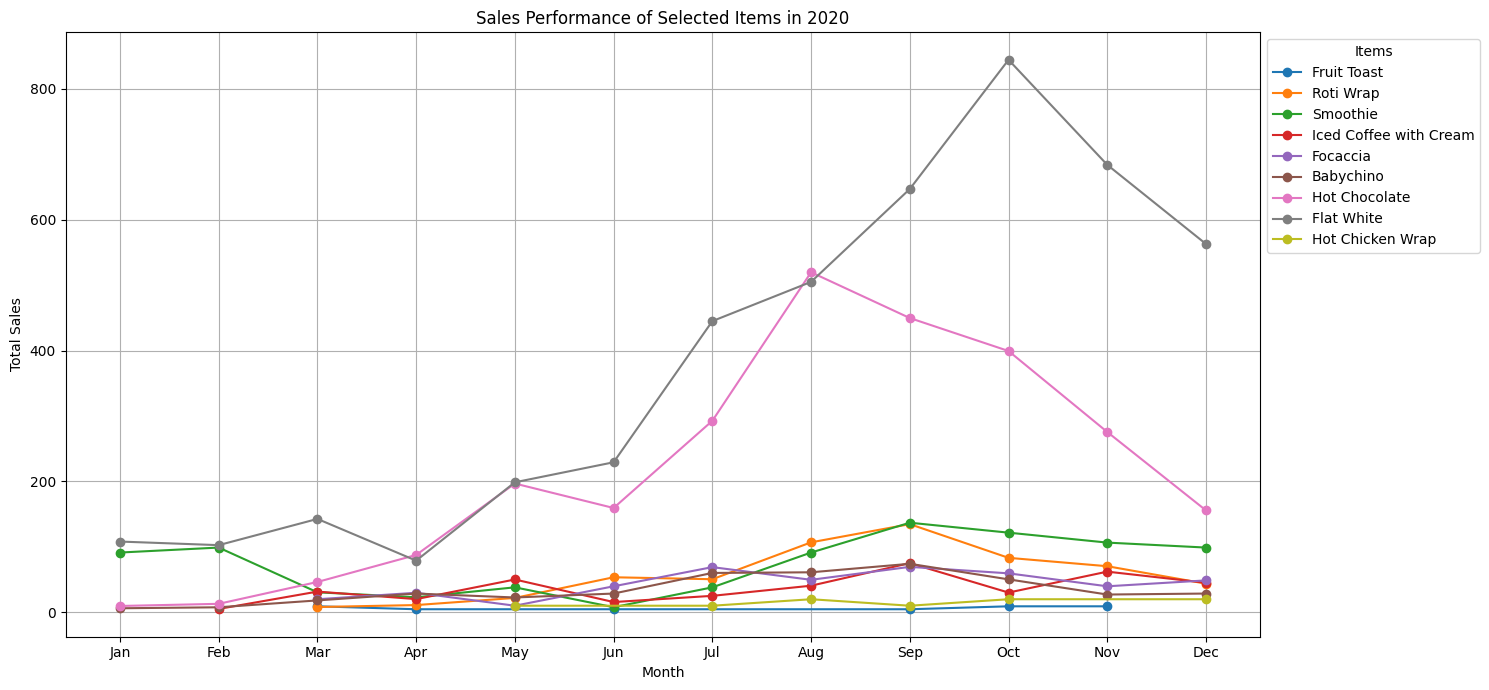

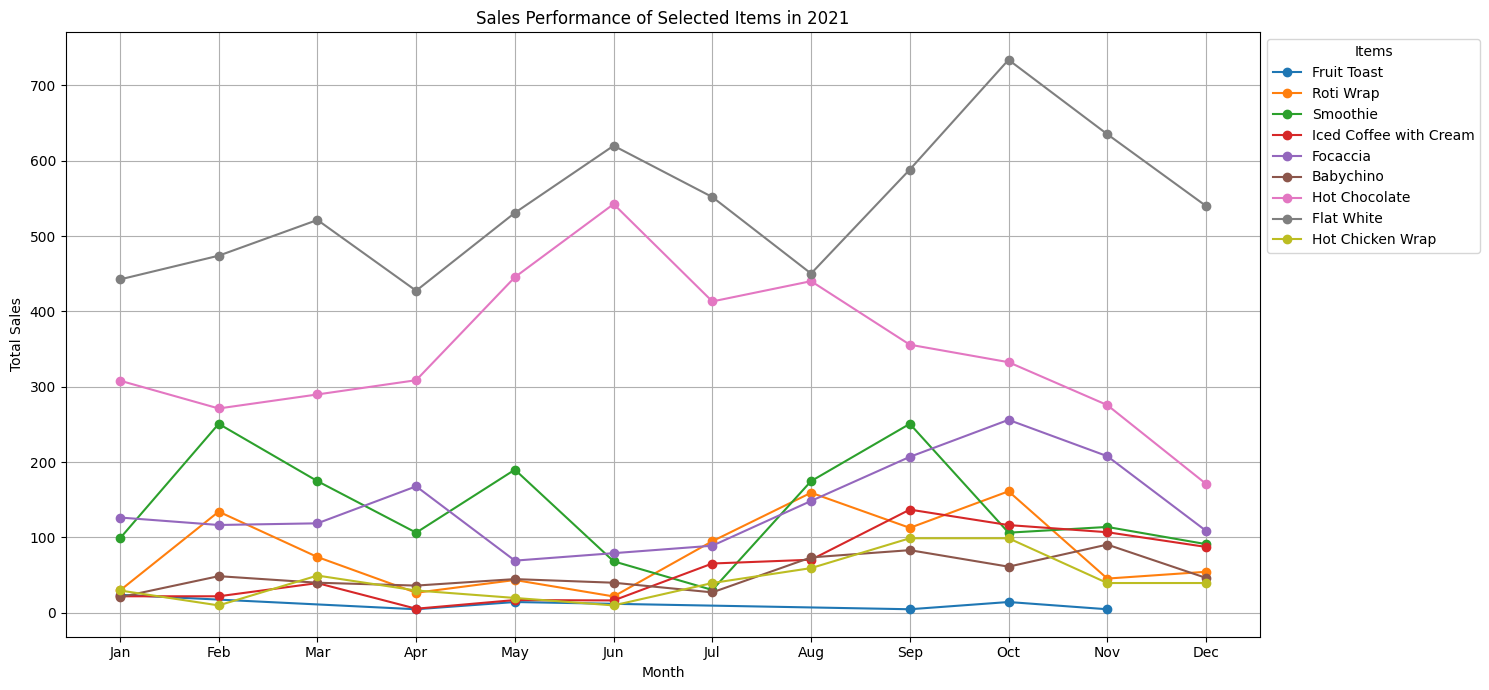

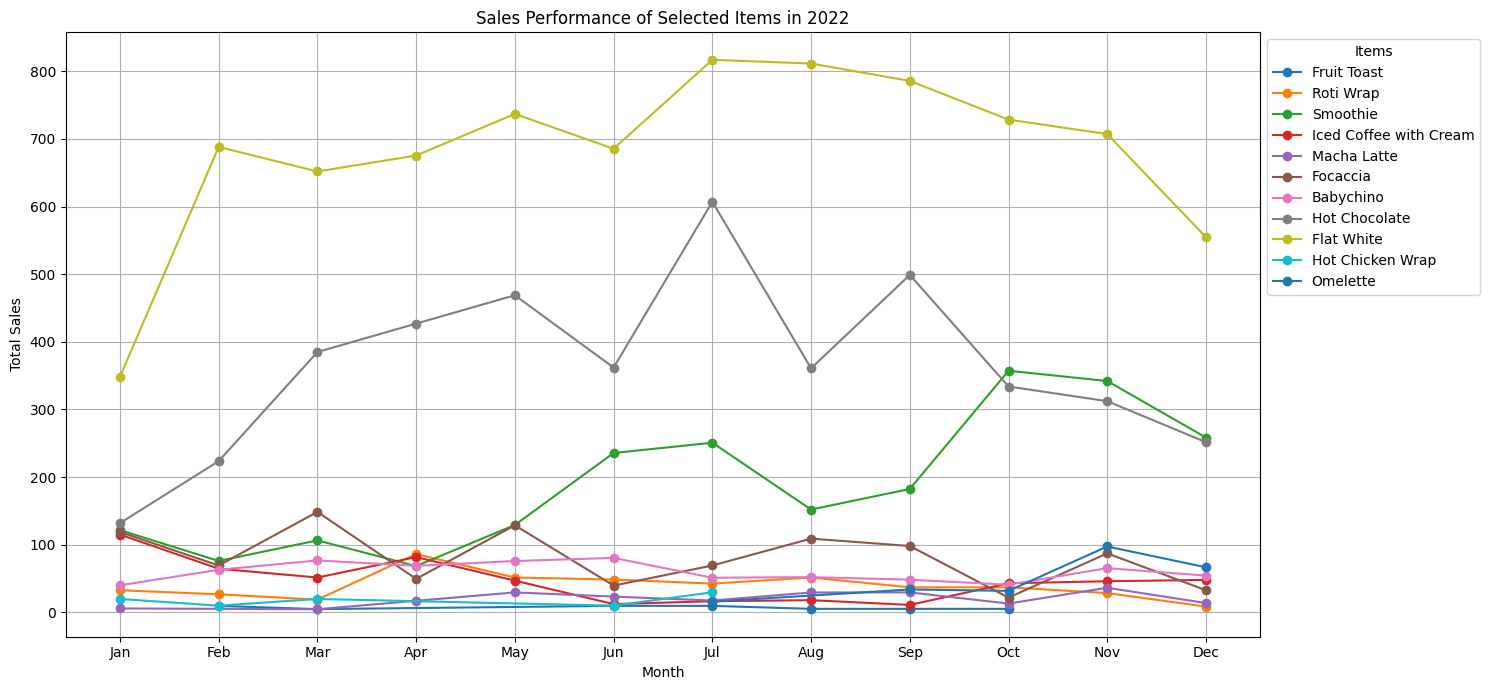

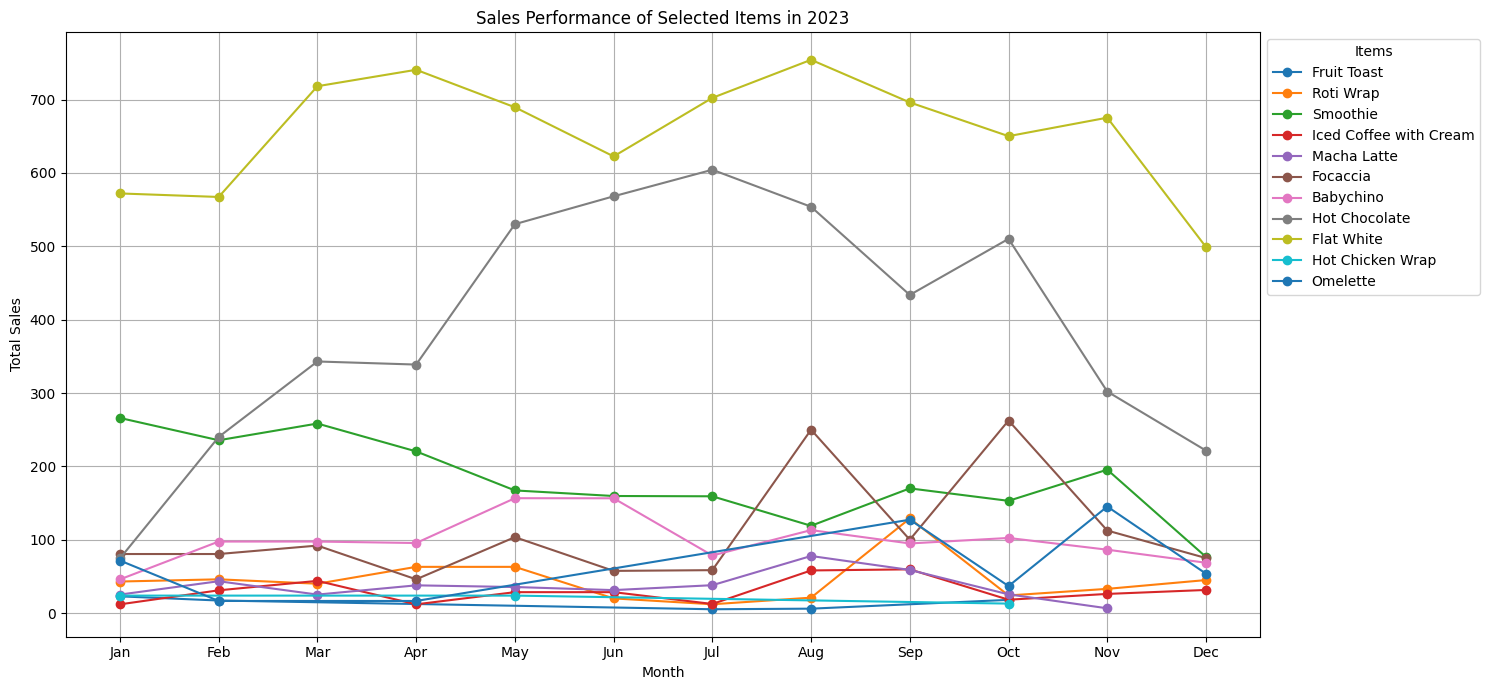

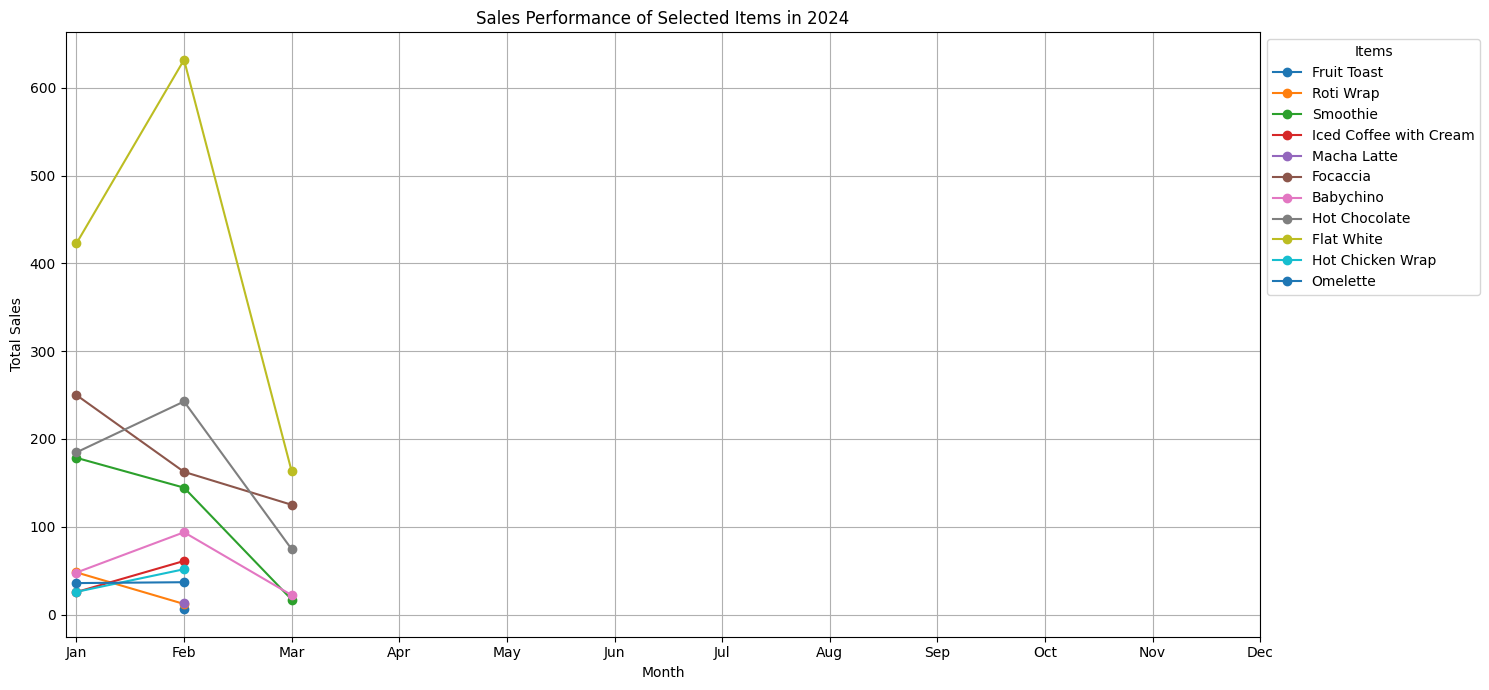

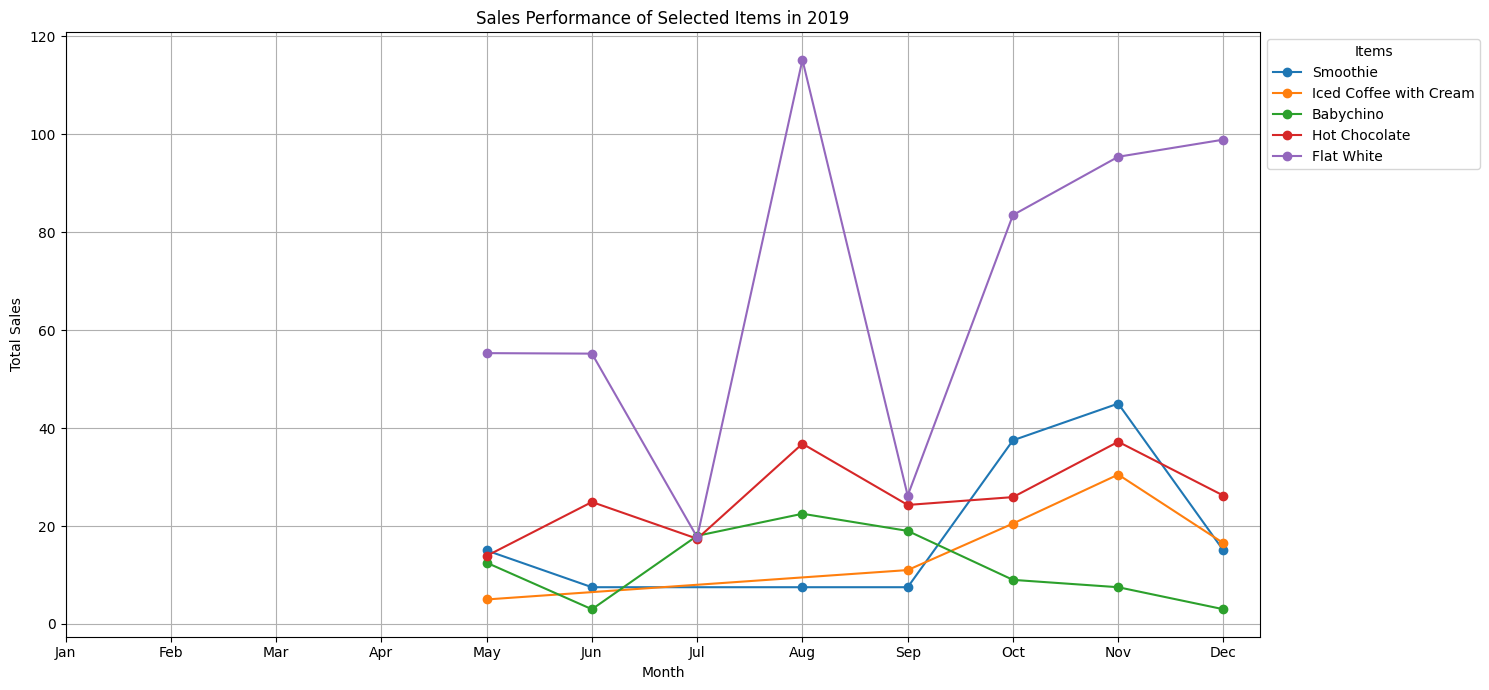

In [14]:
items_to_plot = [
'Fruit Toast',
'Roti Wrap',
'Iced Latte',
'Smoothie',
'Iced Coffee with Cream',
'Macha Latte',
'Focaccia',
'Babychino',
'Hot Chocolate',
'Flat White',
'Hot Chicken Wrap',
'Omelette'
]

# Call the function with the DataFrame and list of products
plot_sales_per_year(sales_with_product_info, items_to_plot)

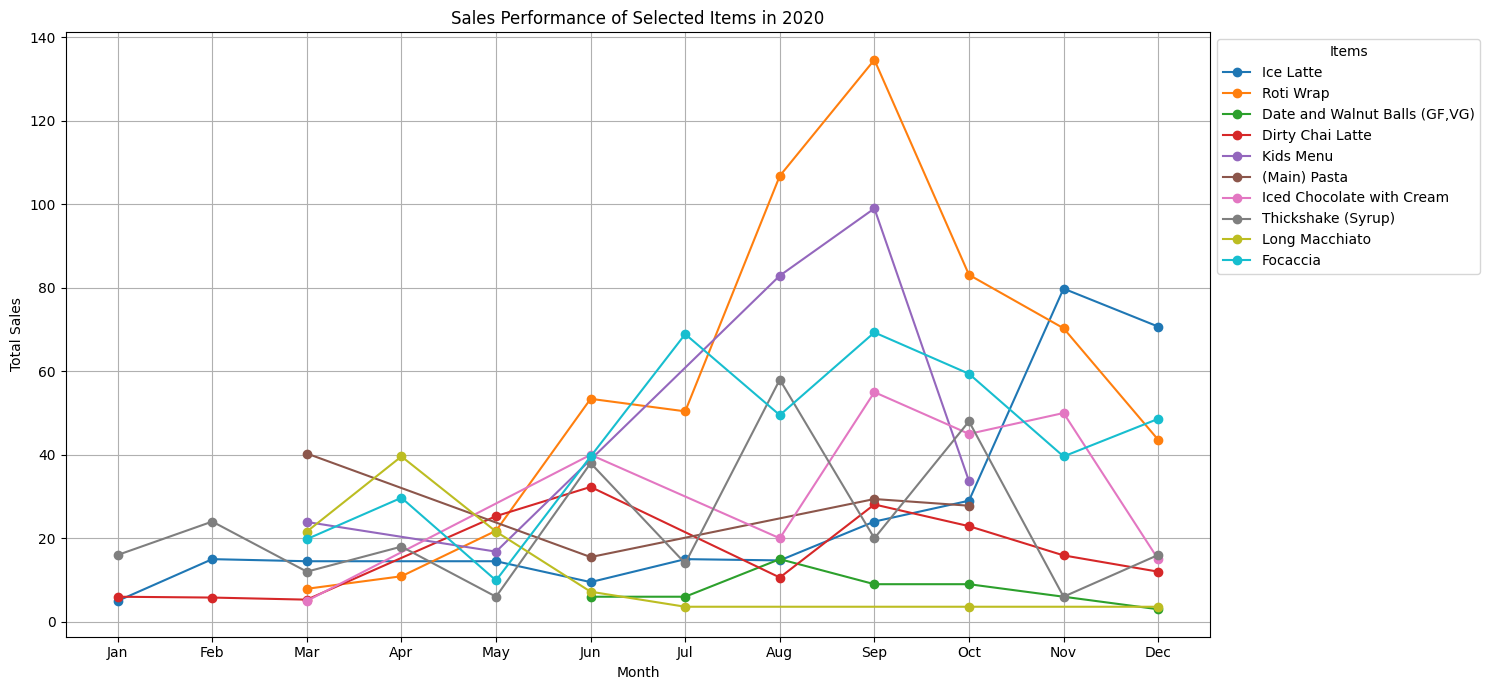

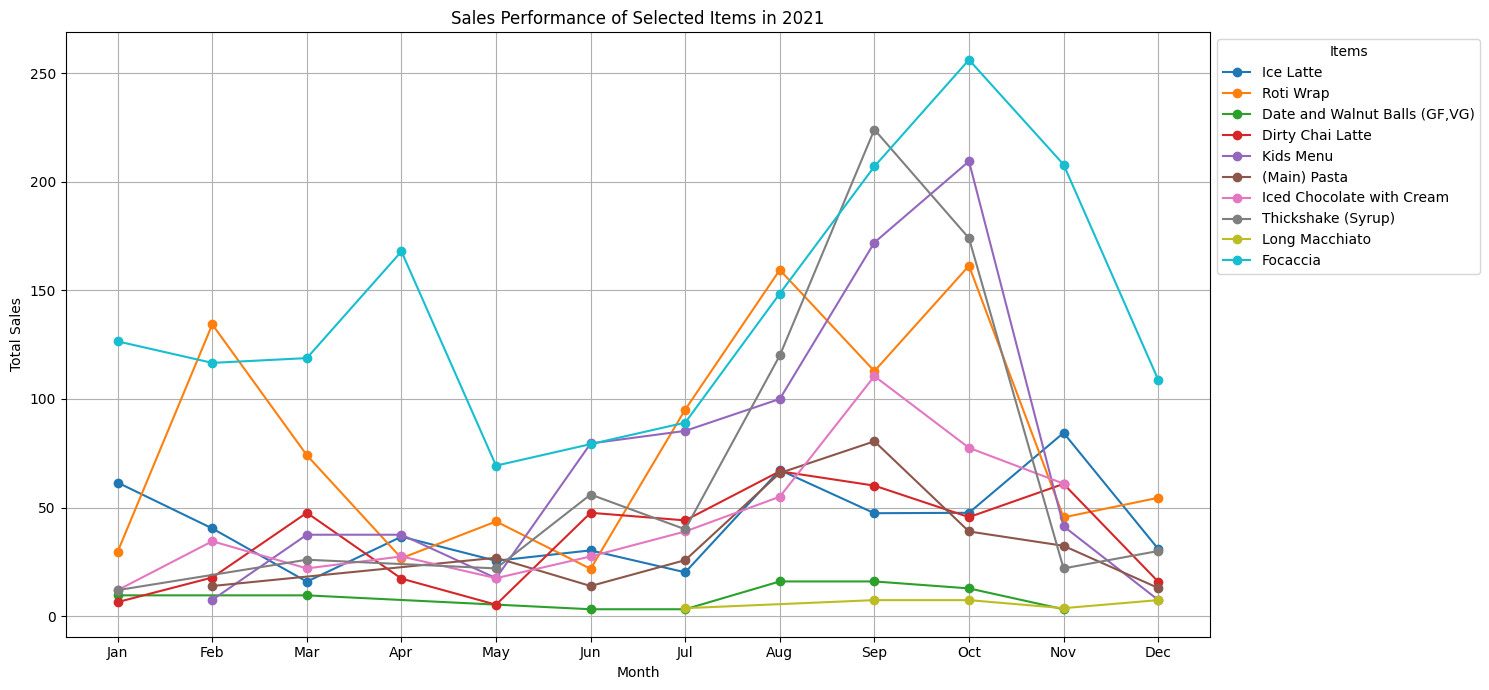

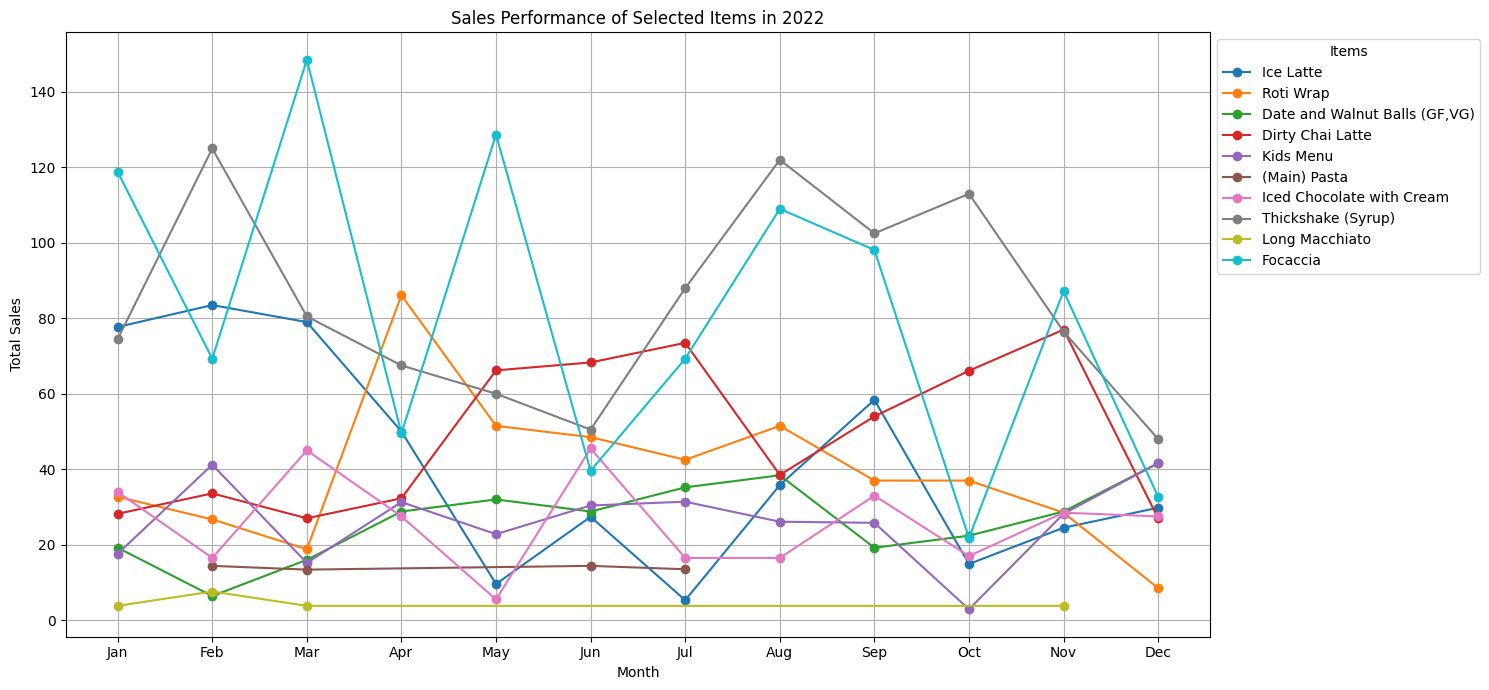

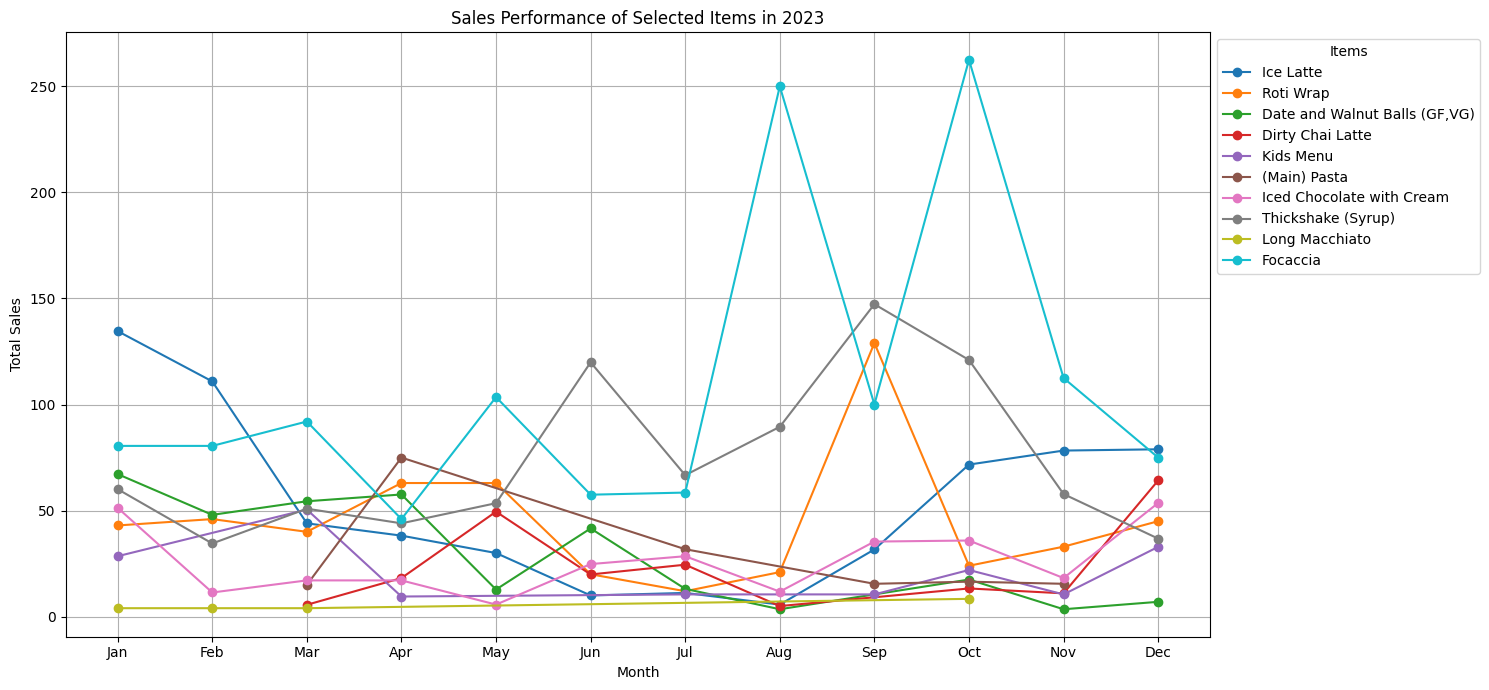

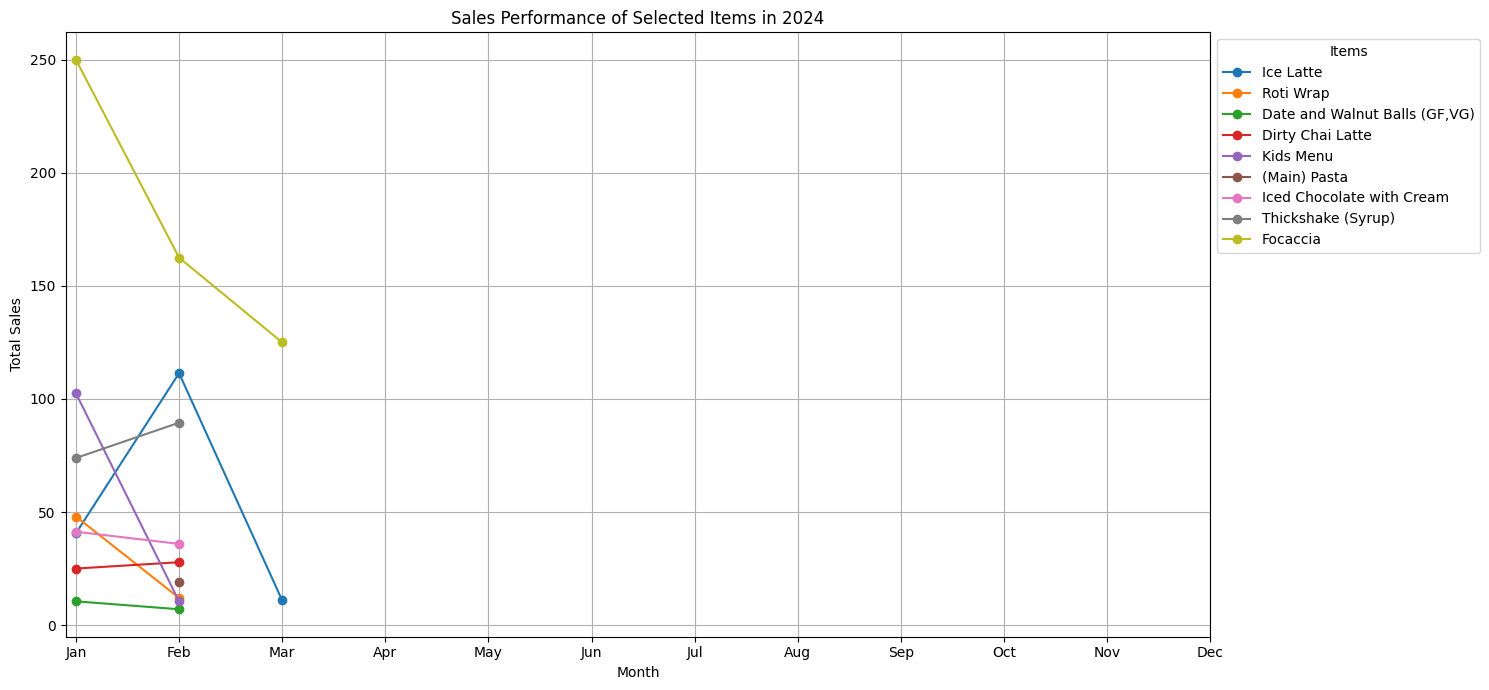

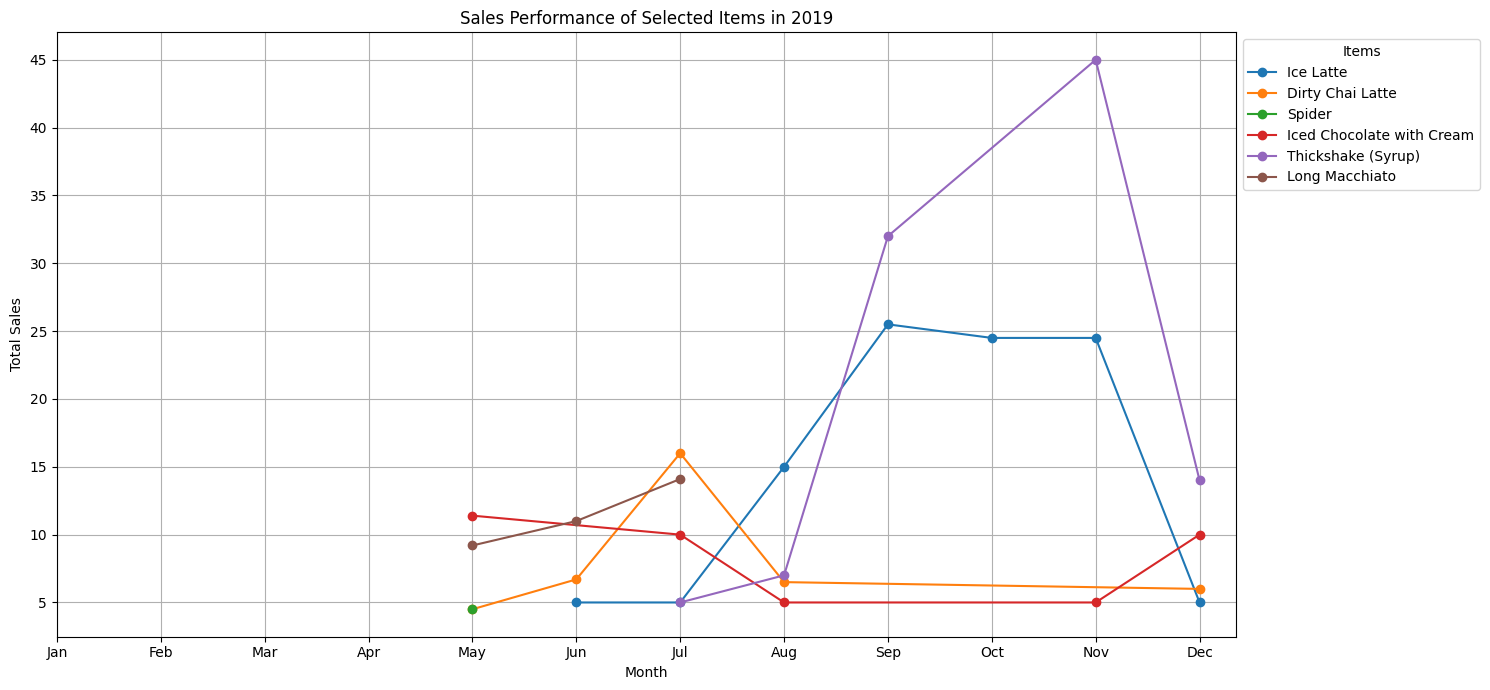

In [15]:



items_to_plot2 = [
"Ice Latte", "Roti Wrap", "Date and Walnut Balls (GF,VG)",
    "Dirty Chai Latte", "Kids Menu", "(Main) Pasta", "Spider", "Iced Chocolate with Cream",
    "Thickshake (Syrup)", "Long Macchiato", "Focaccia"
]

# Call the function with the DataFrame and list of products
plot_sales_per_year(sales_with_product_info, items_to_plot2)

## Probability of a Customer Returning After Purchasing a Specific Item
To find this probability for a specific item (e.g., a latte):

Filter the records to find first purchases where the item was a latte.
Among these filtered records, determine how many of these customers returned.
Calculate the probability 
�
(
return
∣
latte
)
P(return∣latte) as the ratio of returning customers who bought a latte on their first visit to the total number of first-time latte buyers.


1. Transactions on the same day as the purchase are not considered returns.
2. Only transactions within a 60-day window post-purchase are considered valid returns.
3. Taking all orders of every distinct customer into consideration. Not only first purchase.
4. If the Updated Probability of Return is greater than 0.5 and both the upper and lower bounds of the CI are higher than 0.5, it is considered low risk.
5. If the Updated Probability of Return is less than 0.5 and the upper bound of the CI is less than 0.5, it is considered high risk.
6. Otherwise, it is considered moderate risk.

### Probability of product churn for 2022 - 2024

In [52]:
# Function to calculate Wilson confidence intervals
def calculate_wilson_ci(row):
    z = 1.96  # 95% confidence interval
    n = row['Total Sales']
    p = row['Updated Probability of Return']
    if n == 0:
        return pd.Series([0, 0])
    ci_low = (2 * n * p + z**2 - z * np.sqrt(4 * n * p * (1 - p) + z**2)) / (2 * (n + z**2))
    ci_high = (2 * n * p + z**2 + z * np.sqrt(4 * n * p * (1 - p) + z**2)) / (2 * (n + z**2))
    return pd.Series([ci_low, ci_high])

# Filter transactions based on the specified time window
sales_with_product_info_filtered = sales_with_product_info[(sales_with_product_info['date_created'] >= '2022-01-01') & (sales_with_product_info['date_created'] <= '2024-12-31')]

# Convert 'date_created' to datetime and 'customer_id' to integer
sales_with_product_info_filtered['date_created'] = pd.to_datetime(sales_with_product_info_filtered['date_created'])
sales_with_product_info_filtered['customer_id'] = sales_with_product_info_filtered['customer_id'].astype(int)

# Sort sales data by 'customer_id' and 'date_created'
sorted_sales = sales_with_product_info_filtered.sort_values(by=['customer_id', 'date_created'])

# Create a column for the next purchase date by shifting 'date_created' within each customer group
sorted_sales['next_purchase_date'] = sorted_sales.groupby('customer_id')['date_created'].shift(-1)

# Calculate the days to the next purchase
sorted_sales['days_to_next_purchase'] = (sorted_sales['next_purchase_date'] - sorted_sales['date_created']).dt.days

# Filter valid returns: not on the same day and within 60 days post-purchase
valid_returns = sorted_sales[(sorted_sales['days_to_next_purchase'] > 0) & (sorted_sales['days_to_next_purchase'] <= 60)]

# Define date ranges for the last 2 years
date_range_1_start = '2022-03-06'
date_range_1_end = '2023-03-6'
date_range_2_start = '2023-03-7'
date_range_2_end = '2024-03-6'

# Filter transactions within the specified date ranges
filtered_data_1 = valid_returns[(valid_returns['date_created'] >= date_range_1_start) & (valid_returns['date_created'] <= date_range_1_end)]
filtered_data_2 = valid_returns[(valid_returns['date_created'] >= date_range_2_start) & (valid_returns['date_created'] <= date_range_2_end)]

# Count occurrences of each item in valid returns and total sales for each period
item_return_counts_1 = filtered_data_1['item_name'].value_counts()
item_return_counts_2 = filtered_data_2['item_name'].value_counts()

total_item_sales_1 = sales_with_product_info_filtered[(sales_with_product_info_filtered['date_created'] >= date_range_1_start) & (sales_with_product_info_filtered['date_created'] <= date_range_1_end)]['item_name'].value_counts()
total_item_sales_2 = sales_with_product_info_filtered[(sales_with_product_info_filtered['date_created'] >= date_range_2_start) & (sales_with_product_info_filtered['date_created'] <= date_range_2_end)]['item_name'].value_counts()

# Create DataFrames to store the results for each period
results_df_1 = pd.DataFrame(total_item_sales_1).reset_index()
results_df_1.columns = ['Item', 'Total Sales']
results_df_1['Return Counts'] = results_df_1['Item'].map(item_return_counts_1).fillna(0)

results_df_2 = pd.DataFrame(total_item_sales_2).reset_index()
results_df_2.columns = ['Item', 'Total Sales']
results_df_2['Return Counts'] = results_df_2['Item'].map(item_return_counts_2).fillna(0)

# Compute base probabilities for each period
results_df_1['Base Probability of Return'] = results_df_1['Return Counts'] / results_df_1['Total Sales']
results_df_2['Base Probability of Return'] = results_df_2['Return Counts'] / results_df_2['Total Sales']

# Apply Bayesian updating for updated probabilities for each period
prior_counts = 1  # simple prior count
prior_success = prior_counts * 0.5  # naive prior probability of 50%
results_df_1['Updated Probability of Return'] = (results_df_1['Return Counts'] + prior_success) / (results_df_1['Total Sales'] + prior_counts)
results_df_2['Updated Probability of Return'] = (results_df_2['Return Counts'] + prior_success) / (results_df_2['Total Sales'] + prior_counts)

# Find the median number for the Updated Probability of Return for each period
median_updated_probability_1 = results_df_1['Updated Probability of Return'].median()
median_updated_probability_2 = results_df_2['Updated Probability of Return'].median()

# Calculate Wilson confidence intervals for each period
results_df_1[['CI Lower', 'CI Upper']] = results_df_1.apply(calculate_wilson_ci, axis=1)
results_df_2[['CI Lower', 'CI Upper']] = results_df_2.apply(calculate_wilson_ci, axis=1)

# Determine churn risk based on CI intervals relative to the median for each period
def determine_churn_risk(ci_lower, ci_upper, median_prob):
    if ci_lower > median_prob:
        return 'Low'
    elif ci_upper < median_prob:
        return 'High'
    else:
        return 'Moderate'

results_df_1['Churn Risk'] = results_df_1.apply(lambda row: determine_churn_risk(row['CI Lower'], row['CI Upper'], median_updated_probability_1), axis=1)
results_df_2['Churn Risk'] = results_df_2.apply(lambda row: determine_churn_risk(row['CI Lower'], row['CI Upper'], median_updated_probability_2), axis=1)

# Export the results to separate CSV files for each period
#results_df_1.to_csv('conditional_probability_results_2022_to_2023.csv', index=False)
#results_df_2.to_csv('conditional_probability_results_2023_to_2024.csv', index=False)


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/1383441389.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_58869/1383441389.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Churn Risk Analysis

#### Analyse entire 2 years data

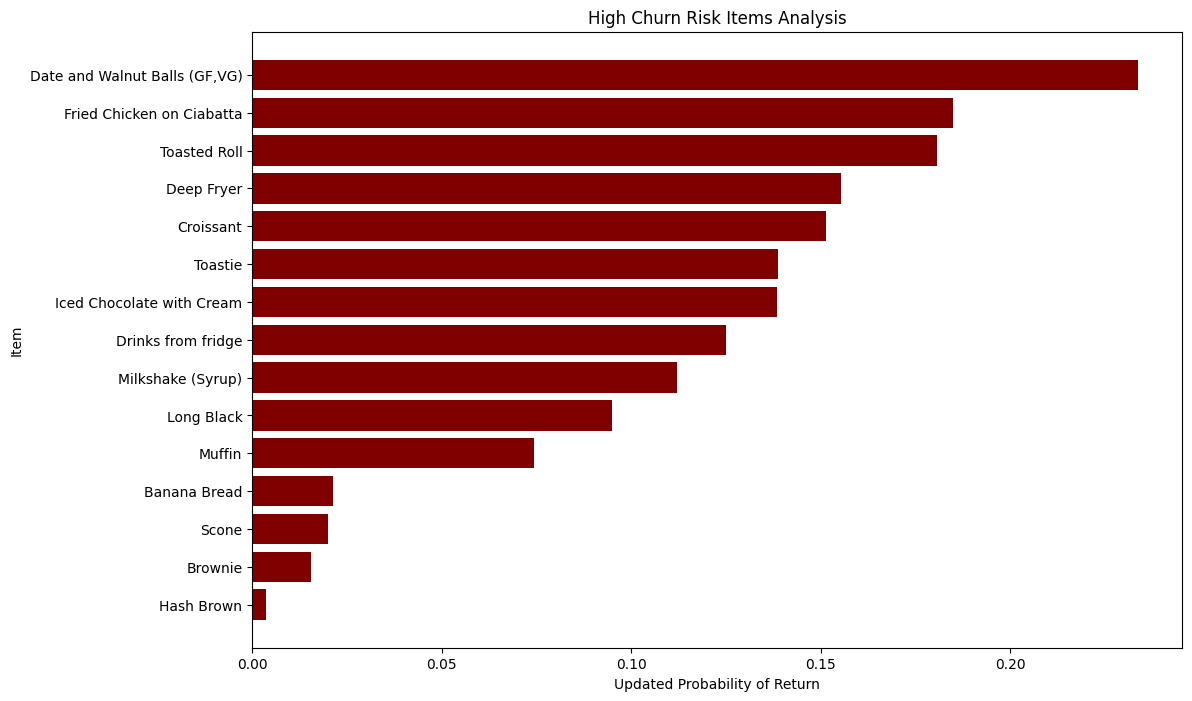

,Item,Updated Probability of Return,Total Sales
3,"Date and Walnut Balls (GF,VG)",0.233607,121
6,Fried Chicken on Ciabatta,0.184932,72
13,Toasted Roll,0.180738,1988
4,Deep Fryer,0.155405,73
2,Croissant,0.151461,391
14,Toastie,0.138572,877
8,Iced Chocolate with Cream,0.138298,46
5,Drinks from fridge,0.125000,19
10,Milkshake (Syrup),0.111963,325
9,Long Black,0.094937,78


In [53]:
# Combine the results for a unified churn risk analysis
combined_results_df = pd.concat([results_df_1, results_df_2])

# Extract items with high churn risk
high_churn_risk_items = combined_results_df[combined_results_df['Churn Risk'] == 'High']

# Group the high churn risk items to calculate the mean probability of return and total sales
high_churn_risk_summary = high_churn_risk_items.groupby('Item').agg({
    'Updated Probability of Return': 'mean',
    'Total Sales': 'sum'
}).reset_index()

# Sorting by 'Updated Probability of Return' to see items with the highest churn risk at the top
high_churn_risk_summary_sorted = high_churn_risk_summary.sort_values('Updated Probability of Return', ascending=False)

# Plot the results
plt.figure(figsize=(12, 8))
plt.barh(high_churn_risk_summary_sorted['Item'], high_churn_risk_summary_sorted['Updated Probability of Return'], color='maroon')
plt.xlabel('Updated Probability of Return')
plt.ylabel('Item')
plt.title('High Churn Risk Items Analysis')
plt.gca().invert_yaxis()  # To display the highest probability at the top
plt.show()

# Return the sorted summary for further inspection
high_churn_risk_summary_sorted


#### Compare 2022/23 and 2023/24 data

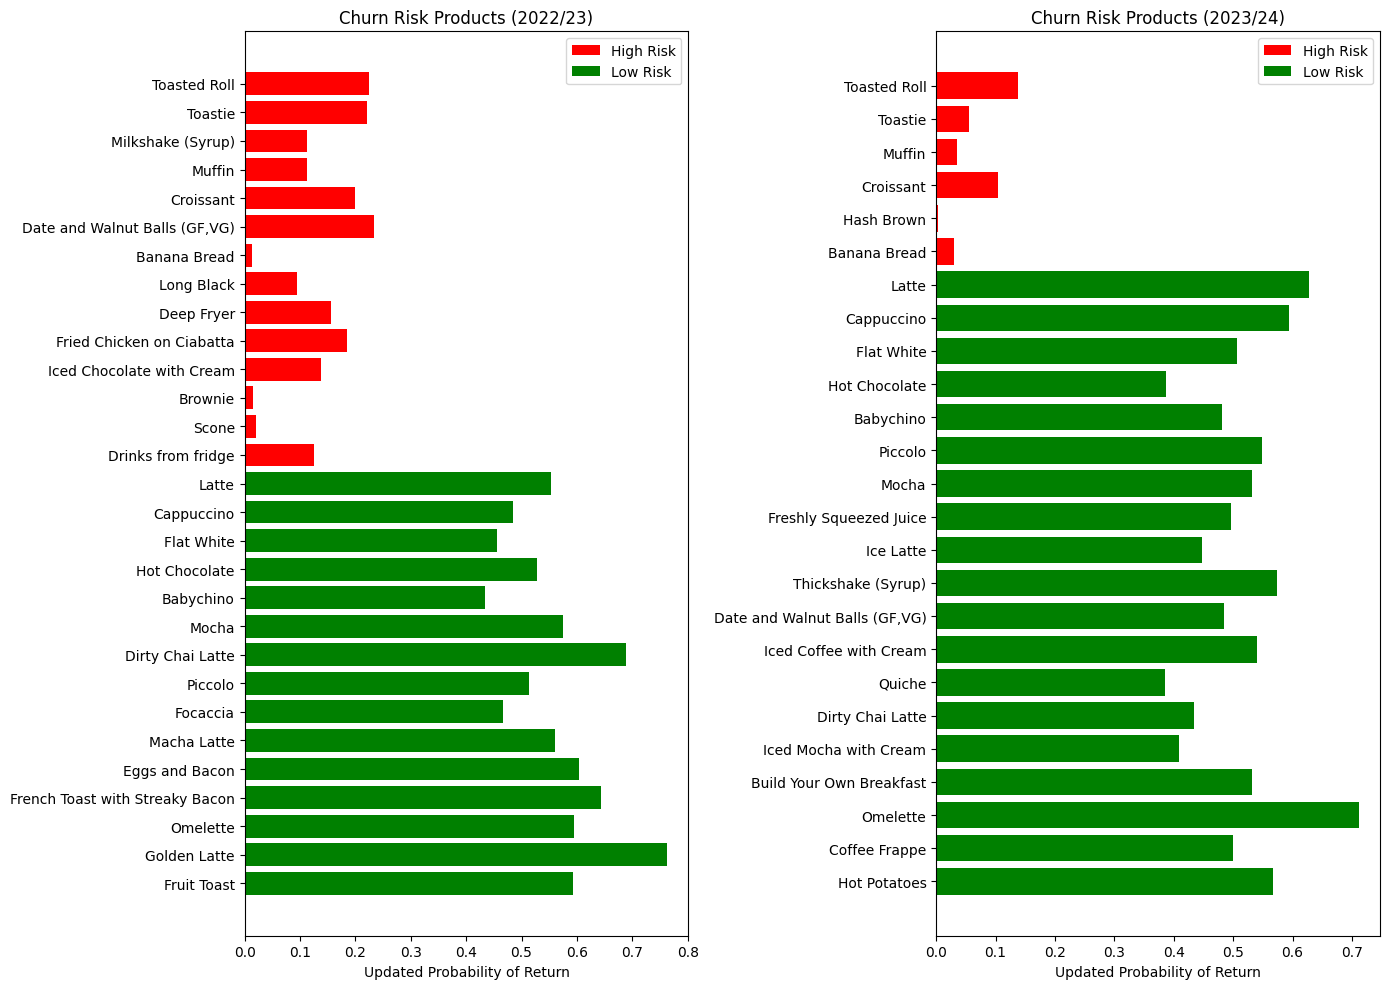

In [54]:
# Plotting high risk and low risk items for 2022/23
plt.figure(figsize=(14, 10))

# High risk items for 2022/2023
high_risk_2022_2023 = results_df_1[results_df_1['Churn Risk'] == 'High']
low_risk_2022_2023 = results_df_1[results_df_1['Churn Risk'] == 'Low']

plt.subplot(1, 2, 1)
plt.barh(high_risk_2022_2023['Item'], high_risk_2022_2023['Updated Probability of Return'], color='red', label='High Risk')
plt.barh(low_risk_2022_2023['Item'], low_risk_2022_2023['Updated Probability of Return'], color='green', label='Low Risk')
plt.xlabel('Updated Probability of Return')
plt.title('Churn Risk Products (2022/23)')
plt.legend()
plt.gca().invert_yaxis()  # Invert the y-axis to have the highest probability at the top

# High risk items for 2023/2024
high_risk_2023_2024 = results_df_2[results_df_2['Churn Risk'] == 'High']
low_risk_2023_2024 = results_df_2[results_df_2['Churn Risk'] == 'Low']

plt.subplot(1, 2, 2)
plt.barh(high_risk_2023_2024['Item'], high_risk_2023_2024['Updated Probability of Return'], color='red', label='High Risk')
plt.barh(low_risk_2023_2024['Item'], low_risk_2023_2024['Updated Probability of Return'], color='green', label='Low Risk')
plt.xlabel('Updated Probability of Return')
plt.title('Churn Risk Products (2023/24)')
plt.legend()
plt.gca().invert_yaxis()  # Invert the y-axis to have the highest probability at the top

# Adjust layout and display the plot
plt.tight_layout()
plt.show()



### RFM Analysis

In [19]:
# Convert date_created to timezone-naive datetime if necessary
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created']).dt.tz_localize(None)

# Filter data for each date range
range_1_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_1_start) &
    (sales_with_product_info['date_created'] <= date_range_1_end)
]

range_2_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_2_start) &
    (sales_with_product_info['date_created'] <= date_range_2_end)
]

# Calculate RFM metrics
def calculate_rfm(data, latest_date):
    return data.groupby('customer_id').agg(
        Recency=('date_created', lambda x: (latest_date - x.max()).days),  # Days since last purchase
        Frequency=('customer_id', 'count'),  # Number of transactions
        Monetary=('total_sales', 'sum')  # Total spent
    )

# Latest dates for recency calculation
latest_date_1 = pd.to_datetime(date_range_1_end) + pd.Timedelta(days=1)
latest_date_2 = pd.to_datetime(date_range_2_end) + pd.Timedelta(days=1)

# RFM dataframes for each range
rfm_1 = calculate_rfm(range_1_data, latest_date_1)
rfm_2 = calculate_rfm(range_2_data, latest_date_2)

# Display first few rows of RFM dataframes
print(rfm_1.head())
print(rfm_2.head())


             Recency  Frequency  Monetary
customer_id                              
8                 23          8      99.2
9                  1        589    3795.6
10                 1         21     157.7
12                 3         15     150.4
13                11         25     162.8
             Recency  Frequency  Monetary
customer_id                              
6                211          3      23.3
8                144          4      42.6
9                  1        404    2574.3
10               157          1       4.2
12               188         40     380.9


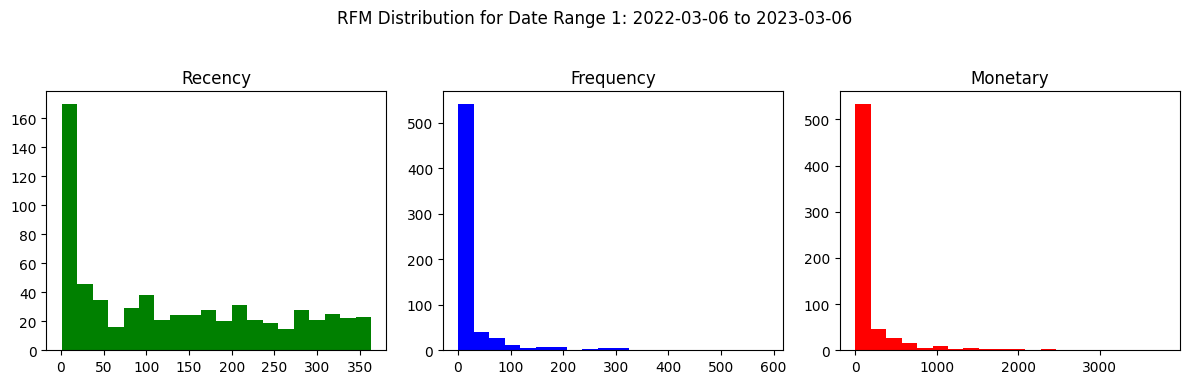

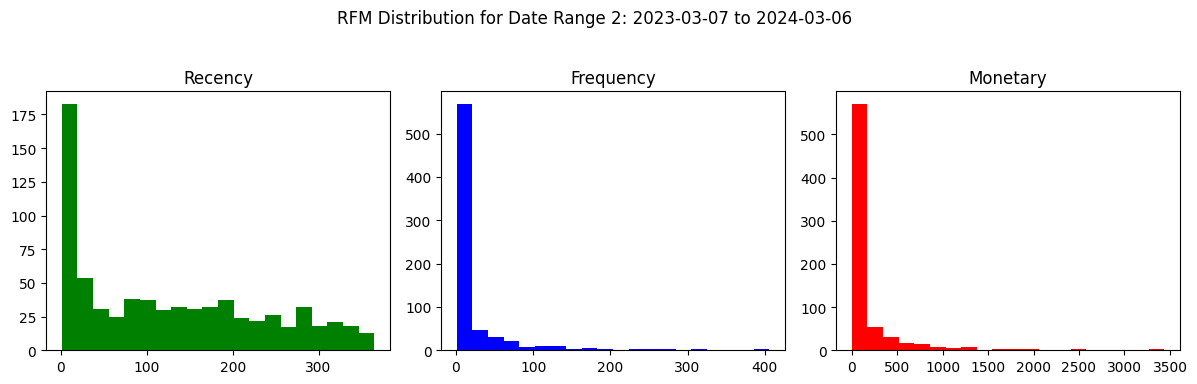

In [32]:
# Function to plot RFM distributions
def plot_rfm_distribution(rfm, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.hist(rfm['Recency'], bins=20, color='green')
    plt.title('Recency')
    plt.subplot(1, 3, 2)
    plt.hist(rfm['Frequency'], bins=20, color='blue')
    plt.title('Frequency')
    plt.subplot(1, 3, 3)
    plt.hist(rfm['Monetary'], bins=20, color='red')
    plt.title('Monetary')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot RFM distributions for each date range
plot_rfm_distribution(rfm_1, 'RFM Distribution for Date Range 1: 2022-03-06 to 2023-03-06')
plot_rfm_distribution(rfm_2, 'RFM Distribution for Date Range 2: 2023-03-07 to 2024-03-06')


- Recency: The green histogram shows the number of days since the last purchase for each customer. Most customers have made a purchase relatively recently, as indicated by the high bar on the left side of the histogram, which represents a lower number of days since the last purchase. This suggests good customer engagement during the period.
- Frequency: The blue histogram illustrates how often customers make purchases. A large number of customers have a low frequency of purchases, as shown by the tall bar on the left, meaning most customers made few transactions. A few customers have higher frequencies, indicating a smaller group of customers who purchase more often.
- Monetary: The red histogram displays how much money customers have spent in total. The majority of customers have lower total spending, which is why there's a tall bar near the left of the histogram. This shows that most customers spend a relatively small amount, while fewer customers have higher total spending, as seen by the long tail stretching to the right.
Interpretation:
- A large segment of customers have made recent purchases but do not purchase frequently and spend lower amounts. This could represent a casual customer base.
- There's a small group of customers who make frequent purchases and contribute more significantly to the total sales. These might be your loyal or high-value customers.
- The long tail in the Monetary histogram suggests there are outliers who spend substantially more than the average customer.

### Correlation between Frequency and Monetary

Correlation between Frequency and Monetary for Date Range 1: 0.9751052367599947


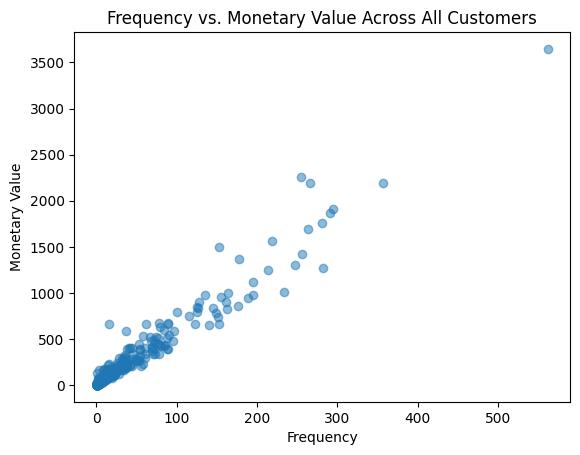

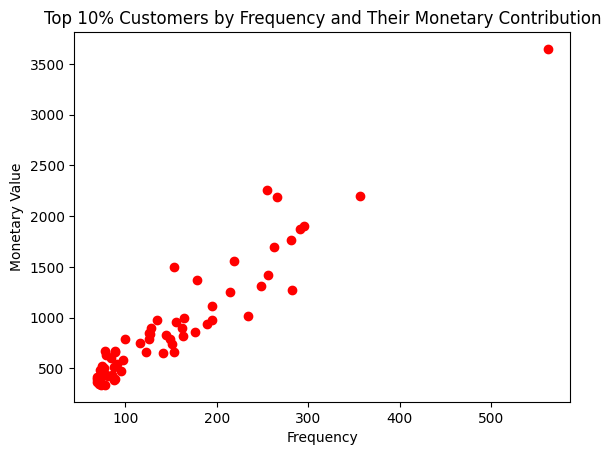

In [21]:
# Ensure the date column is in the proper datetime format
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created'])

# Filter the data for the first date range
filtered_sales_date_range_1 = sales_with_product_info[
    (sales_with_product_info['date_created'] >= '2022-04-06') &
    (sales_with_product_info['date_created'] <= '2023-03-06')
]

# Calculate Frequency (count of transactions) and Monetary (sum of total_sales) values for each customer
rfm_date_range_1 = filtered_sales_date_range_1.groupby('customer_id').agg(
    Frequency=('date_created', 'count'),
    Monetary=('total_sales', 'sum')
)

# Check correlation between Frequency and Monetary
correlation = pearsonr(rfm_date_range_1['Frequency'], rfm_date_range_1['Monetary'])
print(f"Correlation between Frequency and Monetary for Date Range 1: {correlation[0]}")

# Identify the top 10% of customers based on frequency
top_10_percent_threshold = rfm_date_range_1['Frequency'].quantile(0.9)
top_10_customers = rfm_date_range_1[rfm_date_range_1['Frequency'] >= top_10_percent_threshold]

# Calculate their contribution to total sales
total_sales_top_10 = top_10_customers['Monetary'].sum()
total_sales_all = rfm_date_range_1['Monetary'].sum()
top_10_contribution = total_sales_top_10 / total_sales_all

# Plotting Frequency vs. Monetary for all customers
plt.scatter(rfm_date_range_1['Frequency'], rfm_date_range_1['Monetary'], alpha=0.5)
plt.title('Frequency vs. Monetary Value Across All Customers')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.show()

# Plotting for top 10% of customers
plt.scatter(top_10_customers['Frequency'], top_10_customers['Monetary'], color='red')
plt.title('Top 10% Customers by Frequency and Their Monetary Contribution')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.show()



In [22]:
# Filter data for each date range
range_1_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_1_start) &
    (sales_with_product_info['date_created'] <= date_range_1_end)
]

range_2_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_2_start) &
    (sales_with_product_info['date_created'] <= date_range_2_end)
]

# Calculate frequency for each customer in each date range
frequency_range_1 = range_1_data.groupby('customer_id')['date_created'].count()
frequency_range_2 = range_2_data.groupby('customer_id')['date_created'].count()

# Combine frequencies and calculate the top 10% threshold
combined_frequency = pd.concat([frequency_range_1, frequency_range_2], axis=1).fillna(0)
combined_frequency.columns = ['Frequency_2022_2023', 'Frequency_2023_2024']
combined_frequency['Total_Frequency'] = combined_frequency.sum(axis=1)
top_10_percent_threshold = combined_frequency['Total_Frequency'].quantile(0.9)

# Identify the top 10% customers
top_10_customers = combined_frequency[combined_frequency['Total_Frequency'] >= top_10_percent_threshold]

# Calculate total spending for each of the top 10% customers in each date range
top_10_customer_spending_range_1 = range_1_data[range_1_data['customer_id'].isin(top_10_customers.index)].groupby('customer_id')['total_sales'].sum()
top_10_customer_spending_range_2 = range_2_data[range_2_data['customer_id'].isin(top_10_customers.index)].groupby('customer_id')['total_sales'].sum()

# Calculate total sales in each date range
total_sales_range_1 = range_1_data['total_sales'].sum()
total_sales_range_2 = range_2_data['total_sales'].sum()

# Calculate the contribution percentage of each top 10% customer to the total sales in each date range
top_10_customer_spending_range_1_percentage = top_10_customer_spending_range_1 / total_sales_range_1 * 100
top_10_customer_spending_range_2_percentage = top_10_customer_spending_range_2 / total_sales_range_2 * 100

# Combine the results into a single DataFrame
top_10_customer_contributions = pd.DataFrame({
    'Total_Spending_2022_2023($)': top_10_customer_spending_range_1,
    'Contribution_Percentage_2022_2023($)': top_10_customer_spending_range_1_percentage,
    'Total_Spending_2023_2024($)': top_10_customer_spending_range_2,
    'Contribution_Percentage_2023_2024': top_10_customer_spending_range_2_percentage
}).fillna(0)

# Display the DataFrame with top 10% customers' contributions
#top_10_customer_contributions.to_csv('top_10_customer_contributions.csv')


top_10_customer_contributions

,Total_Spending_2022_2023($),Contribution_Percentage_2022_2023($),Total_Spending_2023_2024($),Contribution_Percentage_2023_2024
customer_id,,,,
9,3795.6,3.667569,2574.3,2.141203
16,420.0,0.405833,354.1,0.294527
20,396.5,0.383125,632.1,0.525756
32,717.1,0.692911,785.4,0.653265
40,238.6,0.230552,219.5,0.182572
...,...,...,...,...
1463,0.0,0.000000,1164.3,0.968420
1509,0.0,0.000000,491.2,0.408561
1536,0.0,0.000000,1730.9,1.439696


- top 10% most frequent customers contributed to around 70% of the total sales in 2022/23 and 2023/24 respectively. 

## LTV Customer Analysis
### Step 1: Calculate Annual Average Daily Spending and Annual Current Actual Lifetime

In [26]:
# Filter sales data within the specified date ranges for all customers
range_1_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_1_start) &
    (sales_with_product_info['date_created'] <= date_range_1_end)
]

range_2_data = sales_with_product_info[
    (sales_with_product_info['date_created'] >= date_range_2_start) &
    (sales_with_product_info['date_created'] <= date_range_2_end)
]

# Calculate the first and last purchase dates for each period for all customers
first_last_purchase_range_1 = range_1_data.groupby('customer_id')['date_created'].agg(['min', 'max'])
first_last_purchase_range_2 = range_2_data.groupby('customer_id')['date_created'].agg(['min', 'max'])

# Calculate actual lifetime in days for each period for all customers
actual_lifetime_days_1 = (first_last_purchase_range_1['max'] - first_last_purchase_range_1['min']).dt.days + 1
actual_lifetime_days_2 = (first_last_purchase_range_2['max'] - first_last_purchase_range_2['min']).dt.days + 1

# Calculate total spending for all customers in each period
total_spending_range_1 = range_1_data.groupby('customer_id')['total_sales'].sum()
total_spending_range_2 = range_2_data.groupby('customer_id')['total_sales'].sum()

# Calculate average daily spending for each period for all customers
average_daily_spending_1 = total_spending_range_1 / actual_lifetime_days_1
average_daily_spending_2 = total_spending_range_2 / actual_lifetime_days_2

# Prepare DataFrame to hold all calculated data
all_customer_contributions = pd.DataFrame({
    'Total_Spending_2022_2023': total_spending_range_1,
    'Average_Daily_Spending_2022_2023': average_daily_spending_1,
    'Actual_Lifetime_2022_2023(days)': actual_lifetime_days_1,
    'Total_Spending_2023_2024': total_spending_range_2,
    'Average_Daily_Spending_2023_2024': average_daily_spending_2,
    'Actual_Lifetime_2023_2024(days)': actual_lifetime_days_2
})

# Display the DataFrame with calculations for all customers
all_customer_contributions[['Total_Spending_2022_2023', 'Average_Daily_Spending_2022_2023', 'Actual_Lifetime_2022_2023(days)',
                           'Total_Spending_2023_2024', 'Average_Daily_Spending_2023_2024', 'Actual_Lifetime_2023_2024(days)']]


,Total_Spending_2022_2023,Average_Daily_Spending_2022_2023,Actual_Lifetime_2022_2023(days),Total_Spending_2023_2024,Average_Daily_Spending_2023_2024,Actual_Lifetime_2023_2024(days)
customer_id,,,,,,
6,NaN,NaN,NaN,23.3,23.300000,1.0
8,99.2,0.302439,328.0,42.6,0.196313,217.0
9,3795.6,10.602235,358.0,2574.3,7.052877,365.0
10,157.7,0.466568,338.0,4.2,4.200000,1.0
12,150.4,0.458537,328.0,380.9,2.151977,177.0
...,...,...,...,...,...,...
1752,NaN,NaN,NaN,53.3,53.300000,1.0
1753,NaN,NaN,NaN,4.8,4.800000,1.0
1754,NaN,NaN,NaN,5.3,5.300000,1.0


### Step 2: Find Expected Annual Average Lifetime using Geometric Distribution

Geometric Distribution in Lifetime Estimation:
- The geometric distribution is typically used in this context to model the number of trials (in your case, days) until the first failure (customer churn). In customer relationship terms:

- Churn Rate (𝑝) is the probability that a customer will churn or stop being a customer after any given day.
- Expected Lifetime (1/p) using the geometric distribution is the expected number of days until a customer churns, calculated as the reciprocal of the churn rate.

In [27]:
# Ensure all_customer_contributions has been previously calculated with 'Actual_Lifetime_2022_2023(days)' and 'Actual_Lifetime_2023_2024(days)'
# Convert lifetimes to float and calculate average to avoid integer division issues
average_lifetime_2022_2023 = all_customer_contributions['Actual_Lifetime_2022_2023(days)'].astype(float).mean()
average_lifetime_2023_2024 = all_customer_contributions['Actual_Lifetime_2023_2024(days)'].astype(float).mean()

# Calculate churn rates as the inverse of the average lifetimes
churn_rate_2022_2023 = 1 / average_lifetime_2022_2023 if average_lifetime_2022_2023 != 0 else 0
churn_rate_2023_2024 = 1 / average_lifetime_2023_2024 if average_lifetime_2023_2024 != 0 else 0

# Calculate expected lifetimes using the geometric distribution principle
expected_lifetime_2022_2023 = 1 / churn_rate_2022_2023 if churn_rate_2022_2023 != 0 else float('inf')  
expected_lifetime_2023_2024 = 1 / churn_rate_2023_2024 if churn_rate_2023_2024 != 0 else float('inf')

# Output the expected lifetimes for each year
print("Expected Average Lifetime for 2022-2023:", expected_lifetime_2022_2023, 'days')
print("Expected Average Lifetime for 2023-2024:", expected_lifetime_2023_2024, 'days')


Expected Average Lifetime for 2022-2023: 111.80792682926828 days
Expected Average Lifetime for 2023-2024: 108.1497919556172 days


### Step 4: Calculate LTV for Each Year for Top 10% Loyal Customers

In [69]:
# Assuming 'all_customer_contributions' is prepared and includes the same columns as 'top_10_customer_contributions'

# Calculate LTV for each customer for each year
# LTV = Expected Lifetime * Average Daily Spending

all_customer_contributions['LTV_2022_2023($)'] = (
    all_customer_contributions['Average_Daily_Spending_2022_2023'] * expected_lifetime_2022_2023
)

all_customer_contributions['LTV_2023_2024($)'] = (
    all_customer_contributions['Average_Daily_Spending_2023_2024'] * expected_lifetime_2023_2024
)

# Display the DataFrame with LTV calculations
all_customer_contributions[['Total_Spending_2022_2023', 'Average_Daily_Spending_2022_2023', 'Actual_Lifetime_2022_2023(days)', 'LTV_2022_2023($)',
                            'Total_Spending_2023_2024', 'Average_Daily_Spending_2023_2024', 'Actual_Lifetime_2023_2024(days)', 'LTV_2023_2024($)']]

#all_customer_contributions.to_csv('all_customer_contributions_for_2_years.csv')
all_customer_contributions

,Total_Spending_2022_2023,Average_Daily_Spending_2022_2023,Actual_Lifetime_2022_2023(days),Total_Spending_2023_2024,Average_Daily_Spending_2023_2024,Actual_Lifetime_2023_2024(days),LTV_2022_2023($),LTV_2023_2024($)
customer_id,,,,,,,,
6,NaN,NaN,NaN,23.3,23.300000,1.0,NaN,2519.890153
8,99.2,0.302439,328.0,42.6,0.196313,217.0,33.815080,21.231249
9,3795.6,10.602235,358.0,2574.3,7.052877,365.0,1185.413875,762.767149
10,157.7,0.466568,338.0,4.2,4.200000,1.0,52.166006,454.229126
12,150.4,0.458537,328.0,380.9,2.151977,177.0,51.268025,232.735908
...,...,...,...,...,...,...,...,...
1752,NaN,NaN,NaN,53.3,53.300000,1.0,NaN,5764.383911
1753,NaN,NaN,NaN,4.8,4.800000,1.0,NaN,519.119001
1754,NaN,NaN,NaN,5.3,5.300000,1.0,NaN,573.193897


### Optimisation
#### Step 1: Analyze Churn Risk and Return Probability

Risk Aversion Strategy: If your strategy is to minimize risk and avoid potential negative impacts from products with uncertain performance, using the CI lower bound for churn risk could be more appropriate. This approach would help ensure that decisions are made with a buffer for worse-than-expected outcomes, which is crucial if the negative impact of a high churn rate is significant.


In [64]:
# Identify products with high churn risk
high_risk_2022_2023 = results_df_1[results_df_1['Churn Risk'] == 'High']
low_risk_2022_2023 = results_df_1[results_df_1['Churn Risk'] == 'Low']
high_risk_2023_2024 = results_df_2[results_df_2['Churn Risk'] == 'High']
low_risk_2023_2024 = results_df_2[results_df_2['Churn Risk'] == 'Low']

# using CI lower for risk-averse strategy
high_risk_products_22_23 = high_risk_2022_2023[high_risk_2022_2023['CI Lower'] > high_risk_2022_2023['CI Lower'].quantile(0.75)]
print("High-risk products (conservative) for 22/23:", high_risk_products_22_23['Item'].tolist())

# using CI lower for risk-averse strategy
high_risk_products_23_24 = high_risk_2023_2024[high_risk_2023_2024['CI Lower'] > high_risk_2023_2024['CI Lower'].quantile(0.75)]
print("High-risk products (conservative) for 23/24:", high_risk_products_23_24['Item'].tolist())

High-risk products (conservative) for 22/23: ['Toasted Roll', 'Toastie', 'Croissant', 'Date and Walnut Balls (GF,VG)']
High-risk products (conservative) for 23/24: ['Toasted Roll', 'Croissant']


### Step 2: Identify Replacement Products

In [65]:
# For each high-risk product, find a replacement from the low-risk product list
# The criterion for selection could be based on additional factors like sales volume or return probability
for high_risk_item in high_risk_products_22_23['Item']:
    potential_replacements = low_risk_2022_2023[low_risk_2022_2023['Updated Probability of Return'] >= low_risk_2022_2023['Updated Probability of Return'].quantile(0.75)]
    print(f"Potential replacements for {high_risk_item} in 22/23:", potential_replacements['Item'].tolist())

for high_risk_item in high_risk_products_23_24['Item']:
    potential_replacements = low_risk_2023_2024[low_risk_2023_2024['Updated Probability of Return'] >= low_risk_2023_2024['Updated Probability of Return'].quantile(0.75)]
    print(f"Potential replacements for {high_risk_item} in 23/24:", potential_replacements['Item'].tolist())



Potential replacements for Toasted Roll in 22/23: ['Dirty Chai Latte', 'Eggs and Bacon', 'French Toast with Streaky Bacon', 'Golden Latte']
Potential replacements for Toastie in 22/23: ['Dirty Chai Latte', 'Eggs and Bacon', 'French Toast with Streaky Bacon', 'Golden Latte']
Potential replacements for Croissant in 22/23: ['Dirty Chai Latte', 'Eggs and Bacon', 'French Toast with Streaky Bacon', 'Golden Latte']
Potential replacements for Date and Walnut Balls (GF,VG) in 22/23: ['Dirty Chai Latte', 'Eggs and Bacon', 'French Toast with Streaky Bacon', 'Golden Latte']
Potential replacements for Toasted Roll in 23/24: ['Latte', 'Cappuccino', 'Thickshake (Syrup)', 'Omelette', 'Hot Potatoes']
Potential replacements for Croissant in 23/24: ['Latte', 'Cappuccino', 'Thickshake (Syrup)', 'Omelette', 'Hot Potatoes']


### Step 3: Model Financial Impact

In [71]:
# Example to model the potential impact on LTV
improvement_factor = 1.10  # Assume a 10% improvement in LTV due to better retention

# Apply the improvement factor to the existing LTV for demonstration purposes
all_customer_contributions['Improved_LTV_2022_2023($)'] = all_customer_contributions['LTV_2022_2023($)'] * improvement_factor
all_customer_contributions['Improved_LTV_2023_2024($)'] = all_customer_contributions['LTV_2023_2024($)'] * improvement_factor

# Display the DataFrame with improved LTV calculations
print(all_customer_contributions[['Total_Spending_2022_2023', 'LTV_2022_2023($)', 'Improved_LTV_2022_2023($)',
                                  'Total_Spending_2023_2024', 'LTV_2023_2024($)', 'Improved_LTV_2023_2024($)']])


             Total_Spending_2022_2023  LTV_2022_2023($)  \
customer_id                                               
6                                 NaN               NaN   
8                                99.2         33.815080   
9                              3795.6       1185.413875   
10                              157.7         52.166006   
12                              150.4         51.268025   
...                               ...               ...   
1752                              NaN               NaN   
1753                              NaN               NaN   
1754                              NaN               NaN   
1755                              NaN               NaN   
1756                              NaN               NaN   

             Improved_LTV_2022_2023($)  Total_Spending_2023_2024  \
customer_id                                                        
6                                  NaN                      23.3   
8                           

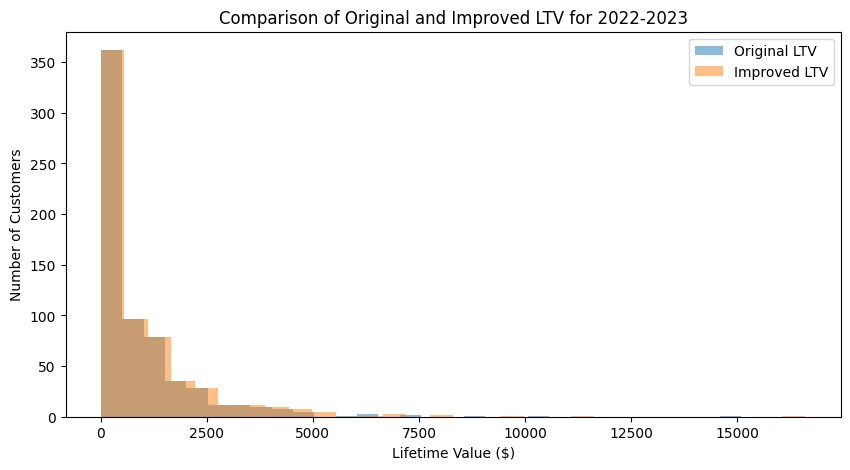

In [72]:
import matplotlib.pyplot as plt

# Example to visualize the original and improved LTV for the year 2022-2023
plt.figure(figsize=(10, 5))
plt.hist(all_customer_contributions['LTV_2022_2023($)'], bins=30, alpha=0.5, label='Original LTV')
plt.hist(all_customer_contributions['Improved_LTV_2022_2023($)'], bins=30, alpha=0.5, label='Improved LTV')
plt.title('Comparison of Original and Improved LTV for 2022-2023')
plt.xlabel('Lifetime Value ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()


In [75]:
all_customer_contributions# Calculate the total historical sales for 2022-2023 and 2023-2024
total_historical_sales_2022_2023 = all_customer_contributions['Total_Spending_2022_2023'].sum()
total_historical_sales_2023_2024 = all_customer_contributions['Total_Spending_2023_2024'].sum()

# Calculate the total improved sales assuming an increase in spending leads to proportional increase in total sales
total_improved_sales_2022_2023 = total_historical_sales_2022_2023 * improvement_factor
total_improved_sales_2023_2024 = total_historical_sales_2023_2024 * improvement_factor

# Calculate the percentage increase in total sales
percentage_increase_2022_2023 = ((total_improved_sales_2022_2023 - total_historical_sales_2022_2023) / total_historical_sales_2022_2023) * 100
percentage_increase_2023_2024 = ((total_improved_sales_2023_2024 - total_historical_sales_2023_2024) / total_historical_sales_2023_2024) * 100

# Display the results
print(f"Total Historical Sales 2022-2023: ${total_historical_sales_2022_2023:,.2f}")
print(f"Total Improved Sales 2022-2023: ${total_improved_sales_2022_2023:,.2f} (Increase by {percentage_increase_2022_2023:.2f}%)")

print(f"Total Historical Sales 2023-2024: ${total_historical_sales_2023_2024:,.2f}")
print(f"Total Improved Sales 2023-2024: ${total_improved_sales_2023_2024:,.2f} (Increase by {percentage_increase_2023_2024:.2f}%)")


Total Historical Sales 2022-2023: $103,490.90
Total Improved Sales 2022-2023: $113,839.99 (Increase by 10.00%)
Total Historical Sales 2023-2024: $120,226.80
Total Improved Sales 2023-2024: $132,249.48 (Increase by 10.00%)
